# Práctica 02 – Análisis estadístico de señales
## Parte 2.5: Acercamiento a la base de datos de arritmias cardiacas y comparación estadística

**Juan Felipe Pereira y Nasser Salam**

**Bioseñales y Sistemas – Bioingeniería, Facultad de Ingeniería**

En esta parte de la práctica trabajamos con la base de datos de ECG de 12 derivaciones de Chapman University y el Shaoxing People's Hospital (disponible en [figshare](https://figshare.com/collections/ChapmanECG/4560497)), descrita por Zheng et al. (2020) en *Scientific Data* [1], [2]. Primero exploramos la base de datos (cuántos registros hay, qué ritmos, cuántos canales, etc.), después miramos en detalle un registro de **bradicardia sinusal (SB)** y uno de **fibrilación auricular (AFIB)**, y al final comparamos estadísticamente estos dos grupos usando seis características calculadas sobre la derivación II de las señales filtradas (carpeta `ECGDataDenoised`).

### Librerías y configuración

Usamos las mismas librerías y convenciones del código base del monitor (pandas, `pathlib.Path`, `FS = 500` y la lista `LEADS`). Las rutas se definen una sola vez en la siguiente celda, así que para correr el notebook en otro computador solo hay que cambiar `CARPETA`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.signal import find_peaks
from matplotlib.patches import Patch

In [2]:
# Configuración (rutas y parámetros generales)
CARPETA = Path(r"C:\Users\felipro\Downloads\ENTREGA 2 BIOSEÑALES")
SIGNALS_DIR = CARPETA / "ECGDataDenoised" / "ECGDataDenoised"
RAW_DIR = CARPETA / "ECGData" / "ECGData"  # señales crudas (solo para comparar)
DIAGNOSTICS_PATH = CARPETA / "Diagnostics.xlsx"
RHYTHM_PATH = CARPETA / "RhythmNames.xlsx"

FS = 500  # Hz
LEADS = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
ALFA = 0.05  # nivel de significancia para todas las pruebas

plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 10

## 1. Exploración y descripción de la base de datos

### 1.1 Archivo de diagnósticos

El archivo `Diagnostics.xlsx` tiene una fila por registro, con el nombre del archivo, el ritmo (`Rhythm`), otras condiciones cardiacas (`Beat`), la edad, el género y algunas medidas que calculó el equipo GE MUSE (frecuencia ventricular, duración del QRS, intervalo QT, etc.).

In [3]:
diagnostics = pd.read_excel(DIAGNOSTICS_PATH)
print("Filas y columnas:", diagnostics.shape)
diagnostics.head()

Filas y columnas: (10646, 16)


,FileName,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QTInterval,QTCorrected,RAxis,TAxis,QRSCount,QOnset,QOffset,TOffset
0,MUSE_20180113_171327_27000,AFIB,RBBB TWC,85,MALE,117,234,114,356,496,81,-27,19,208,265,386
1,MUSE_20180112_073319_29000,SB,TWC,59,FEMALE,52,52,92,432,401,76,42,8,215,261,431
2,MUSE_20180111_165520_97000,SA,NONE,20,FEMALE,67,67,82,382,403,88,20,11,224,265,415
3,MUSE_20180113_121940_44000,SB,NONE,66,MALE,53,53,96,456,427,34,3,9,219,267,447
4,MUSE_20180112_122850_57000,AF,STDD STTC,73,FEMALE,162,162,114,252,413,68,-40,26,228,285,354


### 1.2 Número total de registros y sujetos

In [4]:
n_registros = len(diagnostics)
n_archivos_unicos = diagnostics["FileName"].nunique()

print("Número total de registros:", n_registros)
print("Nombres de archivo (FileName) únicos:", n_archivos_unicos)
print()
print(diagnostics["Gender"].value_counts())

Número total de registros: 10646
Nombres de archivo (FileName) únicos: 10646

Gender
MALE      5956
FEMALE    4690
Name: count, dtype: int64


El archivo tiene 10646 filas y los 10646 valores de `FileName` son distintos, o sea que no hay registros repetidos. Según el artículo de la base de datos [1], a cada paciente se le tomó un único ECG de reposo de 10 s, así que cada registro corresponde a un sujeto diferente. Entonces la base tiene **10646 registros y 10646 sujetos** (5956 hombres y 4690 mujeres), igual a lo que reporta el artículo.

> **Nota aclaratoria sobre el número de registros de AFIB del artículo.** En la introducción los autores dicen que la base tiene *"3,889 subjects with AFIB rhythm"* [1], pero en `Diagnostics.xlsx` hay 1780 registros de AFIB (ver tabla de la sección 1.3) y 3889 es justamente el número de registros de SB, así que parece un error de redacción del artículo. En este trabajo usamos siempre los conteos calculados directamente de `Diagnostics.xlsx`.

### 1.3 Tipos de arritmias (clases) y registros por grupo

In [5]:
rhythm_names = pd.read_excel(RHYTHM_PATH)
rhythm_names.columns = rhythm_names.columns.str.strip()
rhythm_names["Acronym Name"] = rhythm_names["Acronym Name"].str.strip()
rhythm_names

,Acronym Name,Full Name
0,SB,Sinus Bradycardia
1,SR,Sinus Rhythm
2,AFIB,Atrial Fibrillation
3,ST,Sinus Tachycardia
4,AF,Atrial Flutter
5,SI,Sinus Irregularity
6,SVT,Supraventricular Tachycardia
7,AT,Atrial Tachycardia
8,AVNRT,Atrioventricular Node Reentrant Tachycardia
9,AVRT,Atrioventricular Reentrant Tachycardia


> **Nota aclaratoria sobre las siglas SI y SA.** En `RhythmNames.xlsx` la irregularidad sinusal aparece con la sigla SI (*Sinus Irregularity*), pero en `Diagnostics.xlsx` no hay ningún registro con SI y en cambio hay 399 con SA, una sigla que no está en `RhythmNames.xlsx`. Tomamos SA como la irregularidad sinusal por dos razones: (1) de las 11 siglas de cada archivo, diez coinciden y la única pareja sin coincidir es SI–SA (se verifica en la celda siguiente), y (2) a la irregularidad sinusal se le suele llamar *sinus arrhythmia* (arritmia sinusal), cuya sigla es SA. Esto no afecta el análisis estadístico, porque la comparación es solo entre SB y AFIB.

In [6]:
# Verificación de las siglas: qué ritmos están en un archivo y no en el otro
siglas_rhythm_names = set(rhythm_names["Acronym Name"])
siglas_diagnostics = set(diagnostics["Rhythm"])

print("Siglas en común:", sorted(siglas_rhythm_names & siglas_diagnostics))
print("Solo en RhythmNames.xlsx:", sorted(siglas_rhythm_names - siglas_diagnostics))
print("Solo en Diagnostics.xlsx:", sorted(siglas_diagnostics - siglas_rhythm_names))
print("Registros con SI:", (diagnostics["Rhythm"] == "SI").sum(), "| Registros con SA:", (diagnostics["Rhythm"] == "SA").sum())

Siglas en común: ['AF', 'AFIB', 'AT', 'AVNRT', 'AVRT', 'SAAWR', 'SB', 'SR', 'ST', 'SVT']
Solo en RhythmNames.xlsx: ['SI']
Solo en Diagnostics.xlsx: ['SA']
Registros con SI: 0 | Registros con SA: 399


In [7]:
conteo = diagnostics["Rhythm"].value_counts()

# nombre completo de cada ritmo (SA en Diagnostics corresponde a SI en RhythmNames)
nombres = dict(zip(rhythm_names["Acronym Name"], rhythm_names["Full Name"]))
nombres["SA"] = nombres["SI"]

tabla_ritmos = pd.DataFrame({
    "Nombre": [nombres[r] for r in conteo.index],
    "Registros": conteo.values,
    "Porcentaje (%)": (100 * conteo.values / n_registros).round(2),
}, index=conteo.index)
tabla_ritmos.index.name = "Ritmo"
tabla_ritmos

,Nombre,Registros,Porcentaje (%)
Ritmo,,,
SB,Sinus Bradycardia,3889,36.53
SR,Sinus Rhythm,1826,17.15
AFIB,Atrial Fibrillation,1780,16.72
ST,Sinus Tachycardia,1568,14.73
SVT,Supraventricular Tachycardia,587,5.51
AF,Atrial Flutter,445,4.18
SA,Sinus Irregularity,399,3.75
AT,Atrial Tachycardia,121,1.14
AVNRT,Atrioventricular Node Reentrant Tachycardia,16,0.15


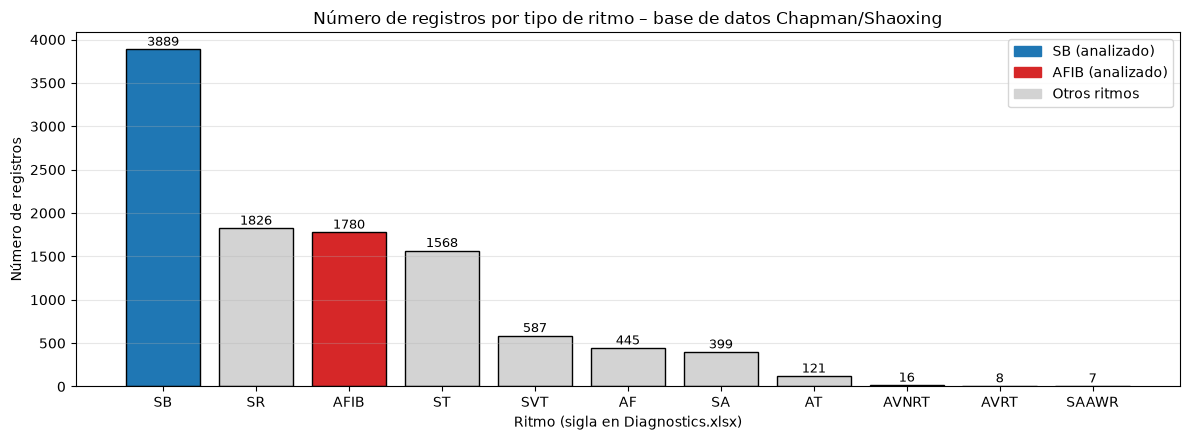

In [8]:
colores = []
for ritmo in conteo.index:
    if ritmo == "SB":
        colores.append("tab:blue")
    elif ritmo == "AFIB":
        colores.append("tab:red")
    else:
        colores.append("lightgray")

plt.figure(figsize=(12, 4.5))
barras = plt.bar(conteo.index, conteo.values, color=colores, edgecolor="black")
for barra, valor in zip(barras, conteo.values):
    plt.text(barra.get_x() + barra.get_width() / 2, valor + 40, str(valor), ha="center", fontsize=9)
leyenda = [Patch(color="tab:blue", label="SB (analizado)"),
           Patch(color="tab:red", label="AFIB (analizado)"),
           Patch(color="lightgray", label="Otros ritmos")]
plt.title("Número de registros por tipo de ritmo – base de datos Chapman/Shaoxing")
plt.xlabel("Ritmo (sigla en Diagnostics.xlsx)")
plt.ylabel("Número de registros")
plt.legend(handles=leyenda)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

La base tiene **11 ritmos**. La clase más grande es SB con 3889 registros (36.53 %), seguida de SR (1826; 17.15 %), AFIB (1780; 16.72 %) y ST (1568; 14.73 %). Entre esos cuatro ritmos está el 85.1 % de la base, mientras que AVNRT (16), AVRT (8) y SAAWR (7) casi no tienen registros. Es decir, la base está bastante desbalanceada; de hecho, para sus pruebas de clasificación los autores agruparon los 11 ritmos en 4 grupos (SB, AFIB, GSVT y SR) [1].

Además del ritmo, la columna `Beat` trae otras condiciones cardiacas del paciente (bloqueos de rama, cambios de la onda T, etc.), cuyas siglas están en `ConditionNames.xlsx`. En este trabajo los grupos se forman solo con la columna `Rhythm`.

Para la comparación escogimos **SB y AFIB**: son dos de los tres grupos más grandes y son dos ritmos muy distintos en su origen (uno es sinusal y el otro es una actividad auricular desorganizada).

### 1.4 Edad y género por grupo

In [9]:
edad = diagnostics.groupby("Rhythm")["PatientAge"].agg(["mean", "std", "min", "max"]).round(1)
edad.columns = ["Edad media", "Edad desv. est.", "Edad mín.", "Edad máx."]
genero = pd.crosstab(diagnostics["Rhythm"], diagnostics["Gender"])
tabla_demografia = edad.join(genero).loc[conteo.index]
tabla_demografia

,Edad media,Edad desv. est.,Edad mín.,Edad máx.,FEMALE,MALE
Ritmo,,,,,,
SB,58.3,14.0,10,98,1408,2481
SR,54.4,16.3,4,95,1024,802
AFIB,73.4,11.1,30,98,739,1041
ST,54.6,21.1,4,96,769,799
SVT,55.6,18.5,4,96,308,279
AF,71.1,13.5,21,97,188,257
SA,34.7,23.0,4,93,176,223
AT,65.7,19.3,8,94,57,64
AVNRT,57.9,17.3,27,84,12,4


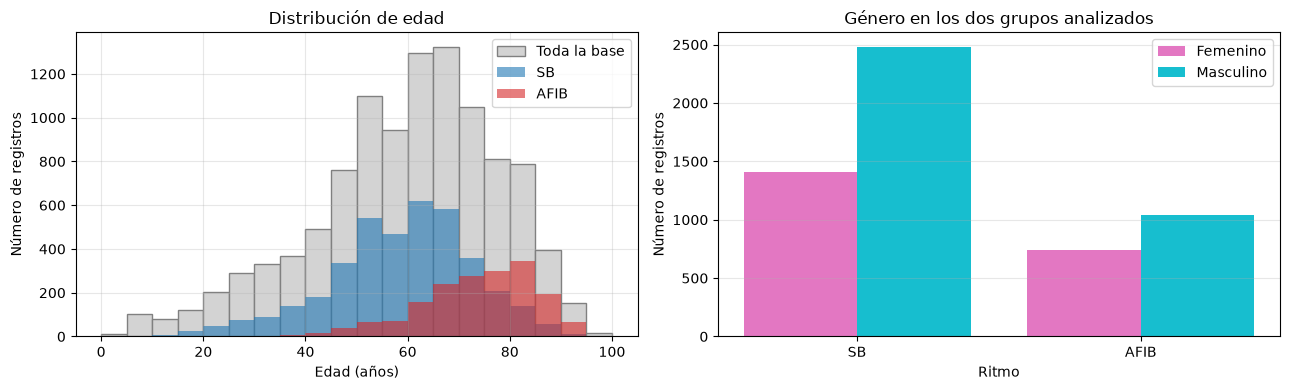

In [10]:
edad_sb = diagnostics[diagnostics["Rhythm"] == "SB"]["PatientAge"]
edad_afib = diagnostics[diagnostics["Rhythm"] == "AFIB"]["PatientAge"]
bordes = np.arange(0, 105, 5)

plt.figure(figsize=(13, 4))

plt.subplot(1, 2, 1)
plt.hist(diagnostics["PatientAge"], bins=bordes, color="lightgray", edgecolor="gray", label="Toda la base")
plt.hist(edad_sb, bins=bordes, color="tab:blue", alpha=0.6, label="SB")
plt.hist(edad_afib, bins=bordes, color="tab:red", alpha=0.6, label="AFIB")
plt.title("Distribución de edad")
plt.xlabel("Edad (años)")
plt.ylabel("Número de registros")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
posiciones = np.arange(2)
mujeres = [genero.loc["SB", "FEMALE"], genero.loc["AFIB", "FEMALE"]]
hombres = [genero.loc["SB", "MALE"], genero.loc["AFIB", "MALE"]]
plt.bar(posiciones - 0.2, mujeres, width=0.4, color="tab:pink", label="Femenino")
plt.bar(posiciones + 0.2, hombres, width=0.4, color="tab:cyan", label="Masculino")
plt.xticks(posiciones, ["SB", "AFIB"])
plt.title("Género en los dos grupos analizados")
plt.xlabel("Ritmo")
plt.ylabel("Número de registros")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Los dos grupos no son iguales en edad: los pacientes con AFIB son en promedio bastante mayores (73.4 ± 11.1 años) que los de SB (58.3 ± 14.0 años), lo que coincide con que la fibrilación auricular es más frecuente a mayor edad [5]. En ambos grupos hay más hombres que mujeres (SB: 2481 hombres y 1408 mujeres; AFIB: 1041 hombres y 739 mujeres). Esto hay que tenerlo en cuenta más adelante: si aparecen diferencias de amplitud entre SB y AFIB, una parte podría deberse a la edad o al género y no solo al tipo de ritmo.

### 1.5 Canales, derivaciones, frecuencia de muestreo y duración

Para confirmar el número de canales, la duración y la frecuencia de muestreo abrimos una muestra de 3 registros de cada uno de los 11 ritmos (los tres primeros de cada ritmo en `Diagnostics.xlsx`), tanto en su versión cruda (`ECGData`) como filtrada (`ECGDataDenoised`). Los archivos crudos traen una fila de encabezado con los nombres de las derivaciones; los filtrados no, por eso se leen con `header=None, names=LEADS`.

In [11]:
# Tomamos los 3 primeros registros de cada ritmo
nombres_muestra = sorted(diagnostics.groupby("Rhythm").head(3)["FileName"])
archivos_muestra = [SIGNALS_DIR / (nombre + ".csv") for nombre in nombres_muestra]
info = diagnostics.set_index("FileName")

filas = []
for archivo in archivos_muestra:
    crudo = pd.read_csv(RAW_DIR / archivo.name, header=0)
    filtrado = pd.read_csv(archivo, header=None, names=LEADS)
    filas.append([archivo.stem, info.loc[archivo.stem, "Rhythm"],
                  crudo.shape[0], crudo.shape[1], filtrado.shape[0], filtrado.shape[1]])

tabla_muestra = pd.DataFrame(filas, columns=["Archivo", "Ritmo", "Muestras crudo", "Canales crudo",
                                             "Muestras filtrado", "Canales filtrado"])
print("Archivos revisados:", len(tabla_muestra))
print("Encabezado de los archivos crudos:", list(crudo.columns))
tabla_muestra.head(6)

Archivos revisados: 33
Encabezado de los archivos crudos: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


,Archivo,Ritmo,Muestras crudo,Canales crudo,Muestras filtrado,Canales filtrado
0,MUSE_20180111_155633_99000,SVT,5000,12,5000,12
1,MUSE_20180111_160708_00000,SVT,5000,12,5000,12
2,MUSE_20180111_163105_37000,SVT,5000,12,5000,12
3,MUSE_20180111_163147_92000,AT,5000,12,5000,12
4,MUSE_20180111_165520_97000,SA,5000,12,5000,12
5,MUSE_20180111_170414_84000,AT,5000,12,5000,12


In [12]:
print("Valores distintos de número de muestras:", sorted(set(tabla_muestra["Muestras crudo"]) | set(tabla_muestra["Muestras filtrado"])))
print("Valores distintos de número de canales:", sorted(set(tabla_muestra["Canales crudo"]) | set(tabla_muestra["Canales filtrado"])))

n_muestras = tabla_muestra["Muestras filtrado"].iloc[0]
duracion = n_muestras / FS
print(f"Duración de cada registro = {n_muestras} muestras / {FS} Hz = {duracion} s")

Valores distintos de número de muestras: [5000]
Valores distintos de número de canales: [12]
Duración de cada registro = 5000 muestras / 500 Hz = 10.0 s


Como verificación extra de que las columnas son las derivaciones que dice el encabezado, usamos la ley de Einthoven: en cualquier instante la derivación II debe ser igual a I + III (el artículo de la base de datos usa esta misma regla para validar los registros).

In [13]:
errores = []
for archivo in archivos_muestra:
    crudo = pd.read_csv(RAW_DIR / archivo.name, header=0)
    diferencia = crudo["II"] - (crudo["I"] + crudo["III"])
    errores.append(np.max(np.abs(diferencia)))

print(f"Máxima diferencia |II - (I + III)| en los {len(errores)} registros crudos: {max(errores):.2f} µV")

Máxima diferencia |II - (I + III)| en los 33 registros crudos: 0.00 µV


Los 33 registros de muestra, tanto crudos como filtrados, tienen 12 canales, que son las 12 derivaciones estándar del ECG: las bipolares de extremidades (I, II, III), las aumentadas (aVR, aVL, aVF) y las precordiales (V1 a V6). Todos tienen 5000 muestras por derivación; con una frecuencia de muestreo de 500 Hz [1] esto da una duración de 10 s por registro. La diferencia máxima entre II e I + III fue de 0.00 µV, así que las columnas sí están en el orden que dice el encabezado. Las amplitudes están en microvoltios (µV) [1].

### 1.6 Archivos filtrados disponibles (ECGDataDenoised)

In [14]:
archivos = sorted(SIGNALS_DIR.glob("*.csv"))
nombres_todos = [a.stem for a in archivos]

print("Archivos CSV en ECGDataDenoised:", len(archivos))
print("¿Todos aparecen en Diagnostics?:", set(nombres_todos).issubset(set(diagnostics["FileName"])))
print()
print("Ritmos de esos archivos:")
print(info.loc[nombres_todos, "Rhythm"].value_counts())

# Para el análisis estadístico solo usamos SB y AFIB
archivos = [a for a in archivos if info.loc[a.stem, "Rhythm"] in ["SB", "AFIB"]]
nombres_archivos = [a.stem for a in archivos]
print()
print("Archivos de SB y AFIB:", len(archivos))

Archivos CSV en ECGDataDenoised: 10646
¿Todos aparecen en Diagnostics?: True

Ritmos de esos archivos:
Rhythm
SB       3889
SR       1826
AFIB     1780
ST       1568
SVT       587
AF        445
SA        399
AT        121
AVNRT      16
AVRT        8
SAAWR       7
Name: count, dtype: int64



Archivos de SB y AFIB: 5669


En la carpeta `ECGDataDenoised` están los 10646 archivos de la base (uno por registro) y todos tienen su fila en `Diagnostics.xlsx`. Para el análisis estadístico solo tomamos los de SB y AFIB, que son 5669. En la sección 3 revisamos archivo por archivo que cada uno tenga realmente 5000 muestras.

**Resumen de la base de datos**

| Aspecto | Valor |
|---|---|
| Registros / sujetos | 10646 / 10646 (un ECG por paciente) |
| Ritmos (clases) | 11: SB, SR, AFIB, ST, SVT, AF, SA, AT, AVNRT, AVRT, SAAWR |
| Canales | 12 derivaciones: I, II, III, aVR, aVL, aVF, V1–V6 |
| Frecuencia de muestreo | 500 Hz |
| Duración | 10 s (5000 muestras por derivación) |
| Unidades | µV |
| Archivos filtrados de SB y AFIB | 5669 (SB = 3889, AFIB = 1780) |

## 2. Visualización y caracterización de las señales

### 2.1 Consulta breve de las dos arritmias escogidas

**Bradicardia sinusal (SB).** Es un ritmo que sigue naciendo en el nodo sinusal (el marcapasos natural del corazón), con despolarización normal, pero con una frecuencia menor a 60 latidos por minuto (lpm). En el ECG se ve como un ritmo sinusal normal pero "más lento": cada QRS va precedido de una onda P de morfología normal, los intervalos RR son regulares y simplemente están más separados. Muchas personas son asintomáticas (por ejemplo deportistas o personas durmiendo), aunque en otros casos puede dar fatiga, mareo o síncope, y puede estar asociada a medicamentos, alteraciones de tiroides o isquemia [4].

**Fibrilación auricular (AFIB).** Es la arritmia sostenida más común. Las aurículas tienen una actividad eléctrica desorganizada y no se contraen de forma efectiva, entonces el nodo AV deja pasar impulsos hacia los ventrículos de forma irregular [5], [6]. En el ECG se reconoce por: (1) ausencia de ondas P claras, reemplazadas por una línea de base ondulada (ondas "f" de fibrilación), (2) intervalos RR "irregularmente irregulares" y (3) frecuencia ventricular que suele ser normal o alta. Clínicamente importa porque aumenta el riesgo de trombos y de accidente cerebrovascular [5], [6].

Con esto ya esperamos dos diferencias claras entre grupos: la **frecuencia cardíaca** (baja en SB, más alta y variable en AFIB) y la **regularidad** de los intervalos RR.

### 2.2 Registros escogidos

Escogimos un registro de SB sin otras condiciones asociadas (`Beat = NONE`) y uno de AFIB en el que se ven bien las ondas f y la irregularidad. Los dos archivos se leen desde `ECGDataDenoised`, igual que en el resto del análisis.

In [15]:
ARCHIVO_SB = "MUSE_20180113_121940_44000"
ARCHIVO_AFIB = "MUSE_20180113_171327_27000"

columnas_meta = ["Rhythm", "Beat", "PatientAge", "Gender", "VentricularRate", "AtrialRate", "QRSDuration", "QRSCount"]
info.loc[[ARCHIVO_SB, ARCHIVO_AFIB], columnas_meta]

,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QRSCount
FileName,,,,,,,,
MUSE_20180113_121940_44000,SB,NONE,66,MALE,53,53,96,9
MUSE_20180113_171327_27000,AFIB,RBBB TWC,85,MALE,117,234,114,19


In [16]:
def titulo_registro(nombre):
    # Título con el mismo formato del código base del monitor
    rhythm = info.loc[nombre, "Rhythm"]
    beat = info.loc[nombre, "Beat"]
    age = info.loc[nombre, "PatientAge"]
    gender = info.loc[nombre, "Gender"]
    return f"Sujeto: {nombre} | Rhythm: {rhythm} | Beat: {beat} | Edad: {age} | Género: {gender}"


ecg_sb = pd.read_csv(SIGNALS_DIR / (ARCHIVO_SB + ".csv"), header=None, names=LEADS)
ecg_afib = pd.read_csv(SIGNALS_DIR / (ARCHIVO_AFIB + ".csv"), header=None, names=LEADS)
t = np.arange(len(ecg_sb)) / FS

print("SB:", ecg_sb.shape, "| AFIB:", ecg_afib.shape, "| duración:", t[-1] + 1 / FS, "s")

SB: (5000, 12) | AFIB: (5000, 12) | duración: 10.0 s


#### Las 12 derivaciones

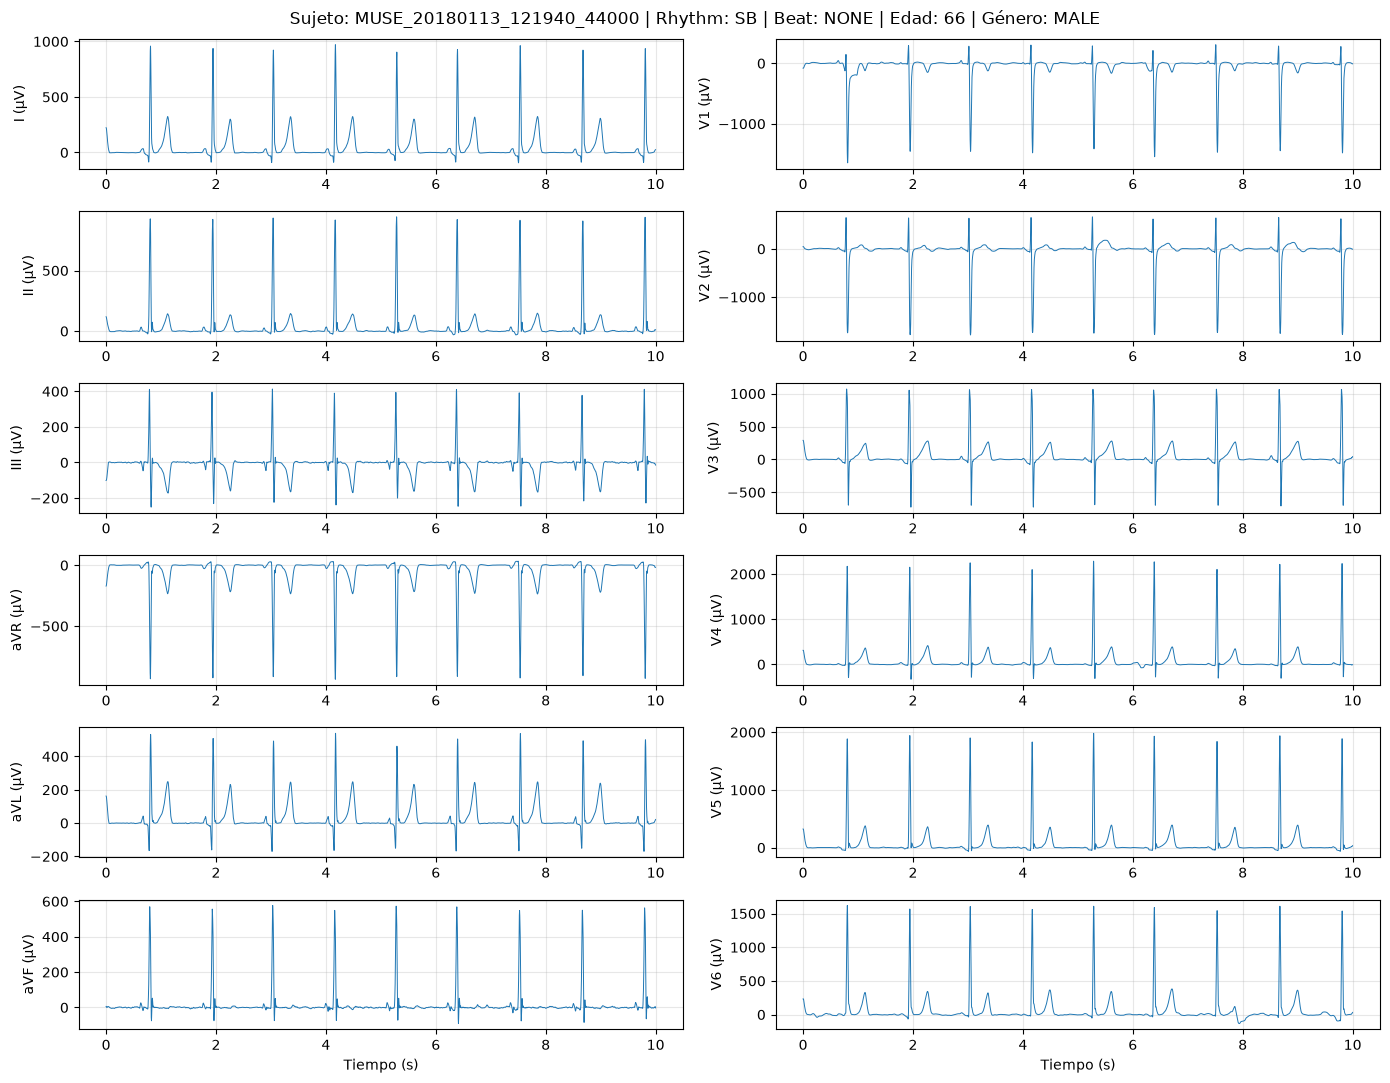

In [17]:
def graficar_12_derivaciones(ecg, nombre, color):
    plt.figure(figsize=(14, 11))
    for i, derivacion in enumerate(LEADS):
        # columna izquierda: I a aVF; columna derecha: V1 a V6
        plt.subplot(6, 2, 2 * (i % 6) + i // 6 + 1)
        plt.plot(t, ecg[derivacion], color=color, linewidth=0.7)
        plt.ylabel(f"{derivacion} (µV)")
        plt.grid(True, alpha=0.3)
        if i % 6 == 5:
            plt.xlabel("Tiempo (s)")
    plt.suptitle(titulo_registro(nombre), fontsize=12)
    plt.tight_layout()
    plt.show()


graficar_12_derivaciones(ecg_sb, ARCHIVO_SB, "tab:blue")

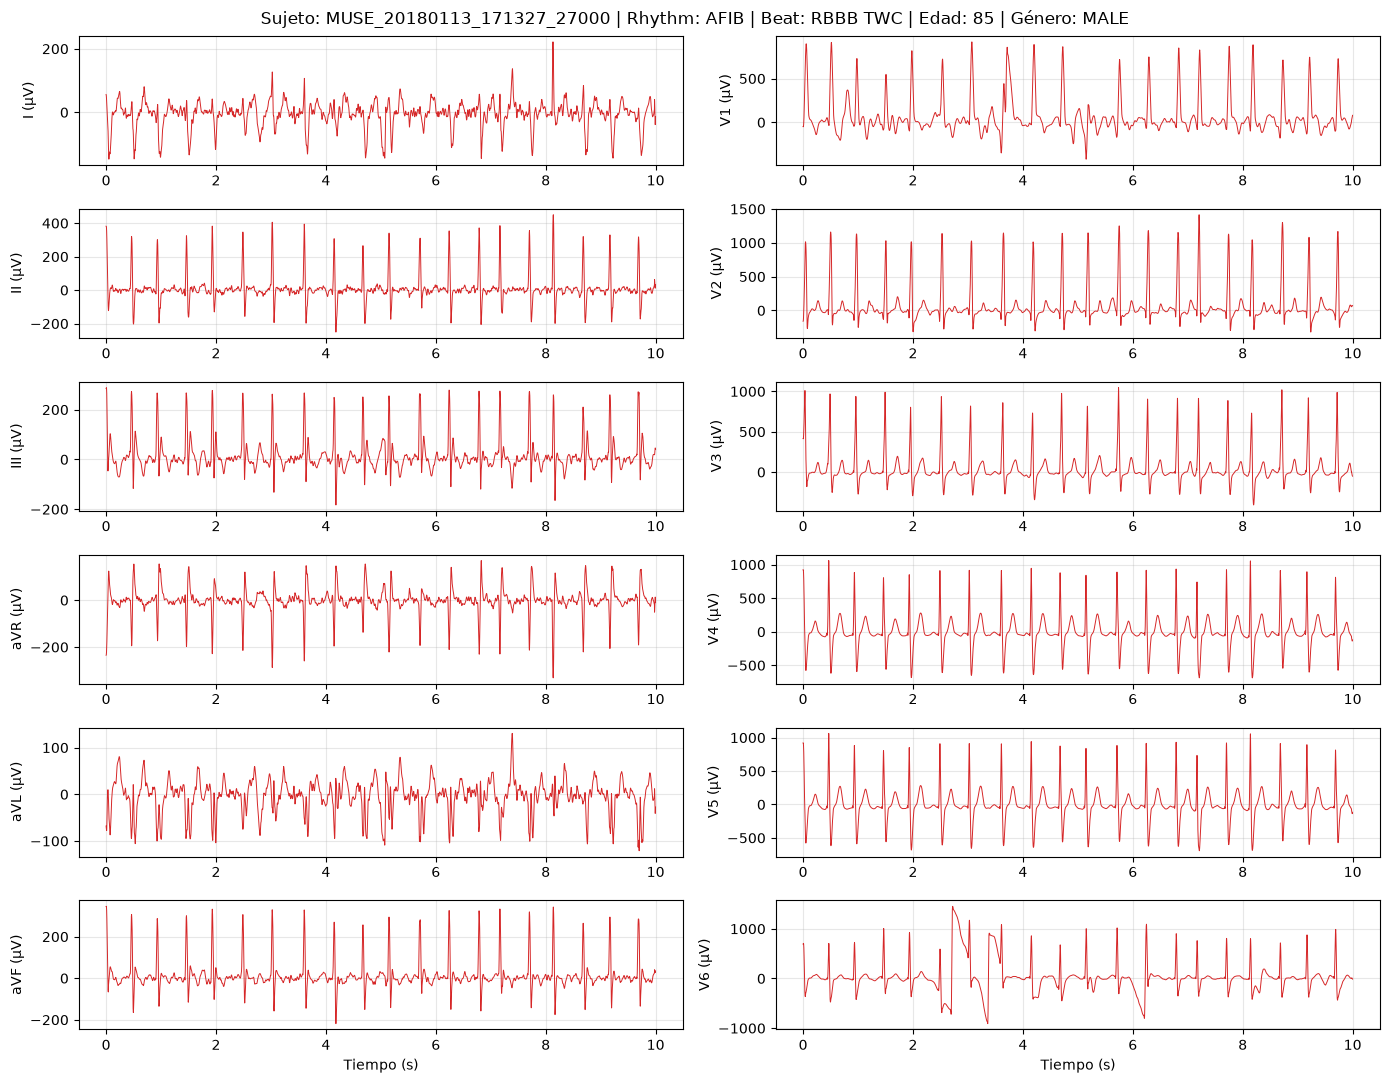

In [18]:
graficar_12_derivaciones(ecg_afib, ARCHIVO_AFIB, "tab:red")

#### Señal cruda vs. filtrada (derivación II)

Solo como referencia visual comparamos la versión cruda (carpeta `ECGData`) con la filtrada. Según el artículo, el filtrado de la base combina un pasa-bajas Butterworth de 50 Hz, la eliminación de la línea de base con LOESS y un suavizado *Non-Local Means* [1].

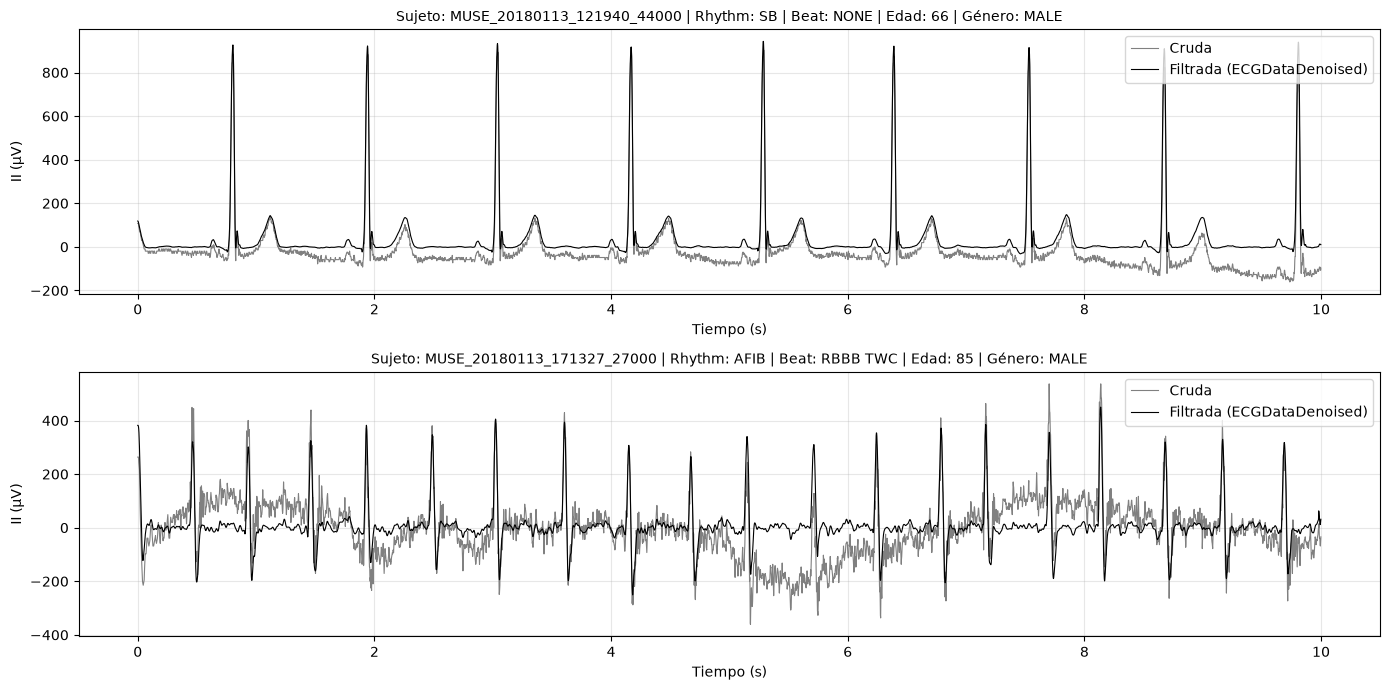

In [19]:
plt.figure(figsize=(14, 7))
for i, nombre in enumerate([ARCHIVO_SB, ARCHIVO_AFIB]):
    crudo = pd.read_csv(RAW_DIR / (nombre + ".csv"), header=0)
    filtrado = pd.read_csv(SIGNALS_DIR / (nombre + ".csv"), header=None, names=LEADS)
    plt.subplot(2, 1, i + 1)
    plt.plot(t, crudo["II"], color="gray", linewidth=0.8, label="Cruda")
    plt.plot(t, filtrado["II"], color="black", linewidth=0.8, label="Filtrada (ECGDataDenoised)")
    plt.ylabel("II (µV)")
    plt.xlabel("Tiempo (s)")
    plt.title(titulo_registro(nombre), fontsize=10)
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

En el registro de SB la señal cruda tiene una deriva de la línea de base (va bajando hasta casi −150 µV al final) y algo de ruido de alta frecuencia; en la filtrada la línea de base queda en cero y se conservan la onda P, el QRS y la onda T. En el registro de AFIB la señal cruda es mucho más ruidosa y la línea de base sube y baja bastante; después del filtro se ven limpios los QRS y queda una línea de base con pequeñas ondulaciones, que pueden corresponder a las ondas f (aunque una parte también puede ser ruido que el filtro no quitó). Por esto tiene sentido trabajar con las señales filtradas: así las medidas de amplitud (máximo, mínimo, media, RMS) no quedan afectadas por la deriva de la línea de base.

### 2.3 Detección de picos R y frecuencia cardíaca

Para calcular la frecuencia cardíaca (FC) necesitamos ubicar los picos R. Primero probamos `scipy.signal.find_peaks` [3] directamente sobre la señal, pero en algunos registros contaba una onda T alta como otro latido o se saltaba latidos cuando había un pico muy grande. Por eso lo aplicamos sobre la derivada al cuadrado. La idea es que el complejo QRS es la parte del ECG con las pendientes más fuertes, así que al derivar y elevar al cuadrado el QRS resalta mucho y las ondas P, T y las ondas f quedan casi en cero. Además, elevar al cuadrado vuelve todo positivo, lo que ayuda en los registros donde el QRS de la derivación II es más negativo que positivo. Usamos estos parámetros:

- `height`: 30 % del percentil 99 de la derivada al cuadrado (usamos el percentil 99 y no el máximo para que un solo pico raro no dañe el umbral).
- `distance`: 0.25 s (125 muestras), porque dos latidos no pueden estar más cerca que eso; equivale a una FC máxima de 240 lpm, suficiente para AFIB rápida.

Después, cada pico encontrado se ajusta al punto de mayor amplitud (en valor absoluto) de la señal original dentro de ±50 ms, que es donde está la onda R (los picos que caen en los primeros o últimos 50 ms del registro se ignoran, porque ese latido puede quedar cortado). Con los picos calculamos los intervalos RR y la FC como:

$$FC = \frac{60}{\overline{RR}} \quad [\text{lpm}], \qquad \overline{RR} \text{ en segundos}$$

In [20]:
def detectar_picos_r(senal, fs=FS):
    # 1) derivada al cuadrado: resalta las pendientes fuertes del QRS
    energia = np.diff(senal) ** 2
    # 2) find_peaks con umbral de altura y distancia mínima entre latidos
    umbral = 0.3 * np.percentile(energia, 99)
    picos, _ = find_peaks(energia, height=umbral, distance=int(0.25 * fs))
    # 3) ubicar la onda R: máximo |amplitud| de la señal en +-50 ms alrededor de cada pico
    ventana = int(0.05 * fs)
    picos_r = []
    for p in picos:
        # se ignoran latidos pegados al inicio o al final, porque el QRS puede quedar cortado
        if p < ventana or p > len(senal) - ventana:
            continue
        tramo = senal[p - ventana:p + ventana]
        picos_r.append(p - ventana + np.argmax(np.abs(tramo)))
    return np.unique(picos_r)


def calcular_fc(picos_r, fs=FS):
    # FC en lpm a partir del promedio de los intervalos RR
    if len(picos_r) < 2:
        return np.nan
    rr = np.diff(picos_r) / fs
    return 60 / np.mean(rr)

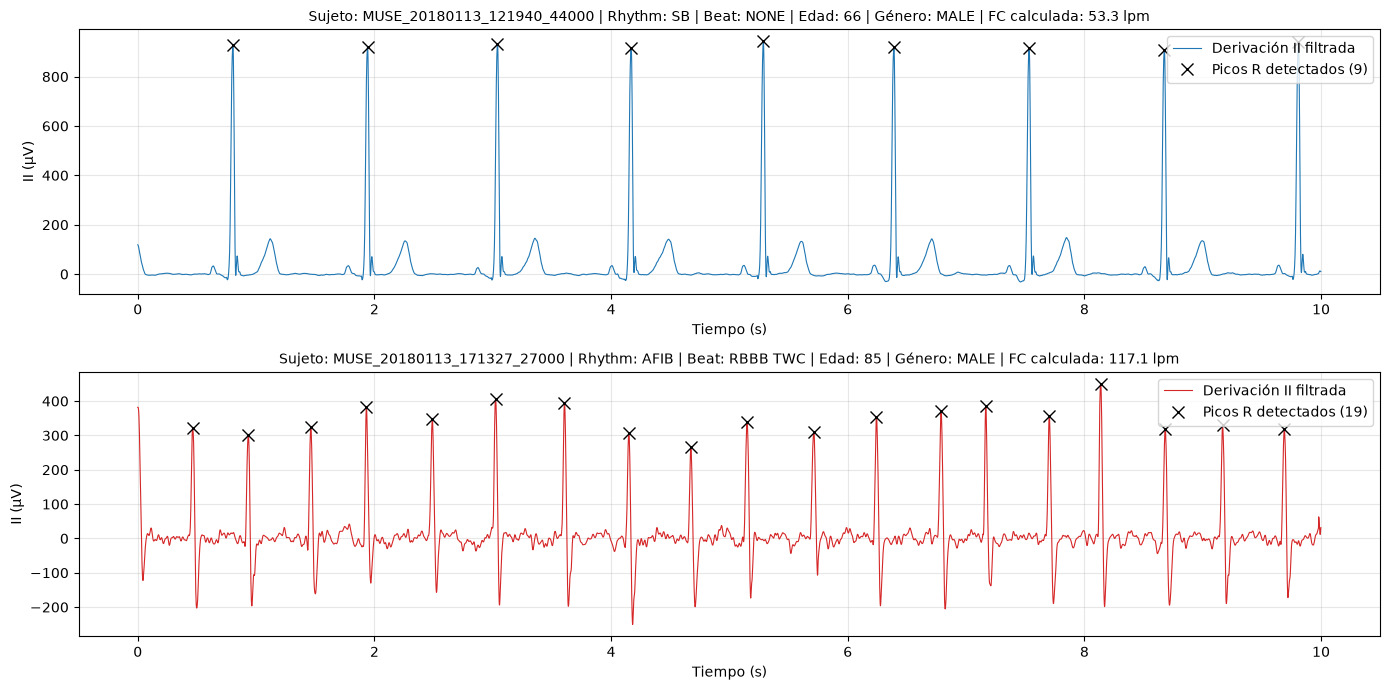

In [21]:
picos_sb = detectar_picos_r(ecg_sb["II"].to_numpy())
picos_afib = detectar_picos_r(ecg_afib["II"].to_numpy())

plt.figure(figsize=(14, 7))
ejemplos = [(ecg_sb, picos_sb, ARCHIVO_SB, "tab:blue"), (ecg_afib, picos_afib, ARCHIVO_AFIB, "tab:red")]
for i, (ecg, picos, nombre, color) in enumerate(ejemplos):
    plt.subplot(2, 1, i + 1)
    plt.plot(t, ecg["II"], color=color, linewidth=0.8, label="Derivación II filtrada")
    plt.plot(t[picos], ecg["II"].to_numpy()[picos], "kx", markersize=8, label=f"Picos R detectados ({len(picos)})")
    plt.ylabel("II (µV)")
    plt.xlabel("Tiempo (s)")
    plt.title(titulo_registro(nombre) + f" | FC calculada: {calcular_fc(picos):.1f} lpm", fontsize=10)
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Zoom a 3 segundos

Para ver mejor la morfología de cada latido (onda P, QRS, onda T o las ondas f) hacemos un acercamiento a los primeros 3 segundos.

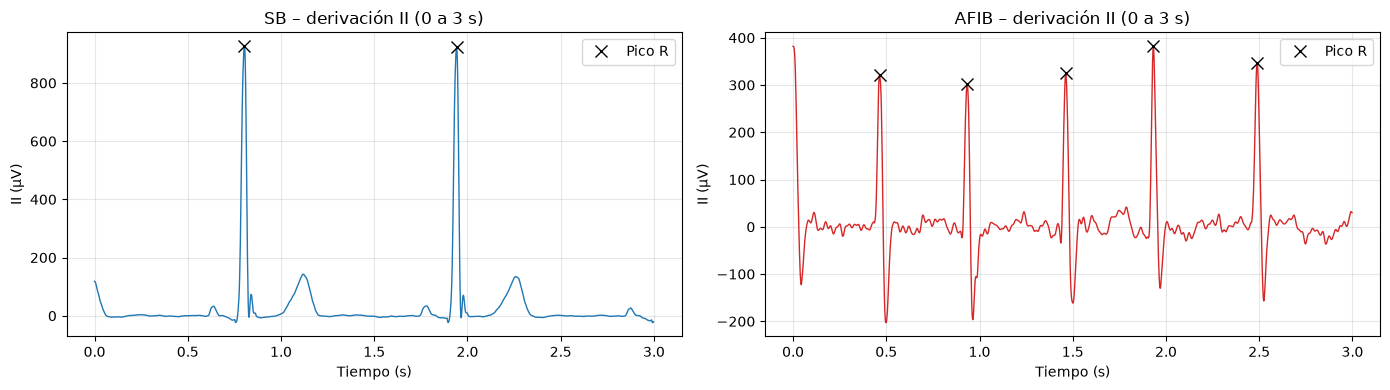

In [22]:
plt.figure(figsize=(14, 4))
for i, (ecg, picos, nombre, color) in enumerate(ejemplos):
    plt.subplot(1, 2, i + 1)
    tramo = t < 3
    plt.plot(t[tramo], ecg["II"][tramo], color=color, linewidth=1)
    picos_tramo = picos[t[picos] < 3]
    plt.plot(t[picos_tramo], ecg["II"].to_numpy()[picos_tramo], "kx", markersize=8, label="Pico R")
    plt.title(f"{info.loc[nombre, 'Rhythm']} – derivación II (0 a 3 s)")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("II (µV)")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Regularidad: intervalos RR

Una forma sencilla de ver la regularidad es graficar cada intervalo RR contra el número de latido (tacograma). En un ritmo regular los puntos quedan casi en una línea horizontal.

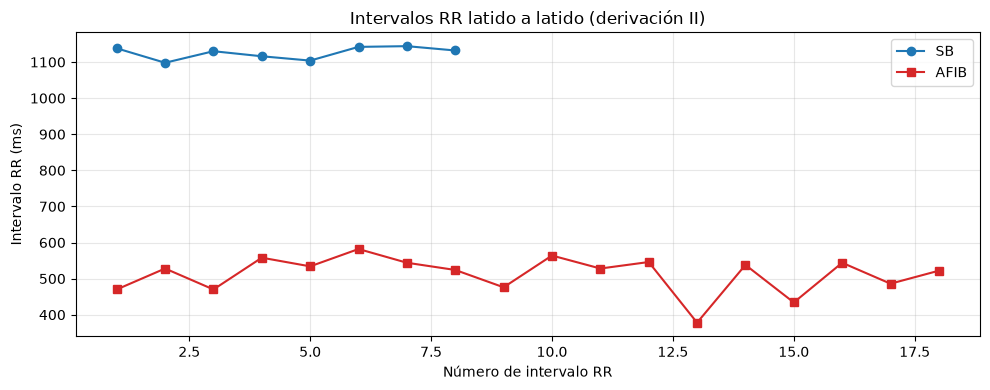

In [23]:
rr_sb = np.diff(picos_sb) / FS
rr_afib = np.diff(picos_afib) / FS

plt.figure(figsize=(10, 4))
plt.plot(np.arange(1, len(rr_sb) + 1), rr_sb * 1000, "o-", color="tab:blue", label="SB")
plt.plot(np.arange(1, len(rr_afib) + 1), rr_afib * 1000, "s-", color="tab:red", label="AFIB")
plt.title("Intervalos RR latido a latido (derivación II)")
plt.xlabel("Número de intervalo RR")
plt.ylabel("Intervalo RR (ms)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
def resumen_registro(ecg, picos, nombre):
    senal = ecg["II"].to_numpy()
    rr = np.diff(picos) / FS
    amplitud_r = senal[picos]
    return {
        "Ritmo": info.loc[nombre, "Rhythm"],
        "Latidos detectados": len(picos),
        "FC calculada (lpm)": round(calcular_fc(picos), 1),
        "FC Diagnostics (lpm)": info.loc[nombre, "VentricularRate"],
        "RR medio (ms)": round(1000 * np.mean(rr), 1),
        "Desv. est. RR (ms)": round(1000 * np.std(rr), 1),
        "CV de RR (%)": round(100 * np.std(rr) / np.mean(rr), 1),
        "RR mín. (ms)": round(1000 * np.min(rr), 1),
        "RR máx. (ms)": round(1000 * np.max(rr), 1),
        "Amplitud R media (µV)": round(np.mean(amplitud_r), 1),
        "Desv. est. amplitud R (µV)": round(np.std(amplitud_r), 1),
    }


tabla_ejemplos = pd.DataFrame([resumen_registro(ecg_sb, picos_sb, ARCHIVO_SB),
                               resumen_registro(ecg_afib, picos_afib, ARCHIVO_AFIB)],
                              index=[ARCHIVO_SB, ARCHIVO_AFIB])
tabla_ejemplos.T

,MUSE_20180113_121940_44000,MUSE_20180113_171327_27000
Ritmo,SB,AFIB
Latidos detectados,9,19
FC calculada (lpm),53.3,117.1
FC Diagnostics (lpm),53,117
RR medio (ms),1125.5,512.6
Desv. est. RR (ms),16.4,49.7
CV de RR (%),1.5,9.7
RR mín. (ms),1098.0,378.0
RR máx. (ms),1144.0,582.0
Amplitud R media (µV),925.1,346.5


### 2.4 Análisis de los dos registros

**Morfología.** En el registro de SB cada QRS va precedido de una onda P pequeña y positiva, el QRS es angosto y alto, y después viene una onda T positiva; entre un latido y el siguiente hay un tramo largo casi plano (isoeléctrico). Es la forma de un ritmo sinusal normal, solo que más lento. En el registro de AFIB no se distingue ninguna onda P antes de los QRS; en su lugar la línea de base tiene oscilaciones pequeñas e irregulares (ondas f). Los QRS de este paciente tienen una R de unos 350 µV seguida de una S profunda (cerca de −200 µV) y son más anchos (QRSDuration = 114 ms frente a 96 ms en el de SB). Esa forma no se debe a la fibrilación en sí, sino a que este paciente también tiene bloqueo de rama derecha (RBBB) y cambios en la onda T (TWC), según la columna `Beat`.

**Amplitud.** La amplitud media de las ondas R fue 925.1 µV en SB y 346.5 µV en AFIB. Esta diferencia es propia de estos dos pacientes (depende del eje eléctrico, la contextura, etc.) y no se puede generalizar; eso es justo lo que se evalúa en la sección 3. Lo que sí nos llamó la atención es que en AFIB la amplitud de la R cambia más de un latido a otro (desviación de 42.6 µV frente a 10.7 µV en SB).

**Frecuencia cardíaca.** La FC calculada fue 53.3 lpm en SB (Diagnostics reporta 53 lpm), por debajo de 60 lpm como corresponde a una bradicardia. En AFIB fue 117.1 lpm (Diagnostics: 117 lpm), es decir, una fibrilación auricular con respuesta ventricular rápida (más de 100 lpm). El primer latido del registro de AFIB (en t ≈ 0 s) no se marca porque cae en los primeros 50 ms y se descarta por estar cortado; como la FC se calcula con el promedio de los RR, esto no la afecta.

**Regularidad.** En SB los RR son casi iguales: 1125.5 ± 16.4 ms, entre 1098 y 1144 ms, con un coeficiente de variación (CV) de apenas 1.5 %; en el tacograma los puntos quedan casi en línea recta. En AFIB los RR van de 378 a 582 ms (512.6 ± 49.7 ms, CV = 9.7 %) y suben y bajan sin ningún patrón, que es el comportamiento "irregularmente irregular" típico de la fibrilación auricular.

## 3. Análisis estadístico entre arritmias (SB vs. AFIB)

Para cada uno de los 5669 archivos filtrados de SB y AFIB tomamos la derivación II completa (10 s) y calculamos las seis características que pide la guía: media, desviación estándar, valor máximo, valor mínimo, frecuencia cardíaca y valor RMS. Escogimos la derivación II porque es la que normalmente se mira para ver el ritmo (en ella la onda P y el QRS suelen verse bien) y porque es la misma del código del monitor.

### 3.1 Cálculo de las características

El valor RMS se calcula con la definición de la guía:

$$x_{RMS} = \left[\frac{1}{N}\sum_{i=1}^{N} x(i)^2\right]^{1/2}$$

Antes de calcular, cada señal pasa por un control de calidad: se descarta si no tiene 5000 muestras, si tiene valores NaN o si es toda ceros. También se descarta si no se logran detectar al menos 2 picos R (no se podría calcular la FC). Para no gastar memoria ni tiempo, de cada archivo solo se lee la columna II (`usecols`).

In [25]:
def calcular_rms(senal):
    return np.sqrt(np.mean(senal ** 2))


def revisar_senal(senal, n_esperado=5000):
    # Devuelve el motivo de descarte, o "ok" si la señal sirve.
    # Criterio de longitud: todos los registros deben durar 10 s (5000 muestras a 500 Hz).
    # Si un archivo tiene menos muestras, sus características (media, desviación, máx, mín, RMS)
    # se calcularían sobre menos latidos y no serían comparables con las de los demás.
    if len(senal) != n_esperado:
        return "longitud distinta"
    if np.isnan(senal).any():
        return "contiene NaN"
    if np.all(senal == 0):
        return "todo ceros"
    return "ok"


def texto_p(p):
    # Con n tan grande algunos p-valores son tan pequeños que el computador los redondea a 0
    if p < 1e-300:
        return "< 1e-300"
    return f"{p:.3e}"

In [26]:
filas = []
descartados = []
longitudes = []

for i, archivo in enumerate(archivos):
    nombre = archivo.stem
    ritmo = info.loc[nombre, "Rhythm"]
    senal = pd.read_csv(archivo, header=None, names=LEADS, usecols=["II"])["II"].to_numpy()
    longitudes.append(len(senal))

    motivo = revisar_senal(senal)
    if motivo == "ok":
        picos = detectar_picos_r(senal)
        fc = calcular_fc(picos)
        if np.isnan(fc):
            motivo = "menos de 2 picos R"

    if motivo != "ok":
        descartados.append([nombre, ritmo, motivo, len(senal)])
    else:
        filas.append([nombre, ritmo, np.mean(senal), np.std(senal), np.max(senal), np.min(senal),
                      fc, calcular_rms(senal), info.loc[nombre, "VentricularRate"]])

    if (i + 1) % 500 == 0 or (i + 1) == len(archivos):
        print(f"{i + 1} de {len(archivos)} archivos procesados")

resultados = pd.DataFrame(filas, columns=["Archivo", "Ritmo", "Media", "Desviacion", "Maximo", "Minimo",
                                          "FC", "RMS", "FC_Diagnostics"])
tabla_descartados = pd.DataFrame(descartados, columns=["Archivo", "Ritmo", "Motivo", "Muestras"])

500 de 5669 archivos procesados


1000 de 5669 archivos procesados


1500 de 5669 archivos procesados


2000 de 5669 archivos procesados


2500 de 5669 archivos procesados


...

4000 de 5669 archivos procesados


4500 de 5669 archivos procesados


5000 de 5669 archivos procesados


5500 de 5669 archivos procesados


5669 de 5669 archivos procesados


### 3.2 Control de calidad y verificación de la frecuencia cardíaca

In [27]:
print("Número de muestras por archivo (conteo de archivos):")
print(pd.Series(longitudes).value_counts())
print()
print("Registros descartados:", len(tabla_descartados))
tabla_descartados

Número de muestras por archivo (conteo de archivos):
5000    5668
1926       1
Name: count, dtype: int64

Registros descartados: 1


,Archivo,Ritmo,Motivo,Muestras
0,MUSE_20180113_124215_52000,SB,longitud distinta,1926


In [28]:
leidos = info.loc[nombres_archivos, "Rhythm"].value_counts()
analizados = resultados["Ritmo"].value_counts()
tabla_calidad = pd.DataFrame({"Archivos leídos": leidos, "Descartados": leidos - analizados, "Analizados": analizados})
tabla_calidad.loc["Total"] = tabla_calidad.sum()
tabla_calidad

,Archivos leídos,Descartados,Analizados
SB,3889,1,3888
AFIB,1780,0,1780
Total,5669,1,5668


De los 5669 archivos, 5668 tienen 5000 muestras. Solo descartamos uno: `MUSE_20180113_124215_52000` (SB), que tiene 1926 muestras. En la celda siguiente se ve que su versión cruda (`ECGData`) sí dura 10 s, o sea que lo que quedó cortado fue el archivo filtrado. No lo cambiamos por la señal cruda porque la guía pide trabajar con los filtrados, y dejarlo así tampoco servía, porque sus características saldrían de menos latidos que las de los demás. No apareció ningún archivo con NaN, todo en ceros ni con menos de 2 picos R, así que quedan **3888 registros de SB y 1780 de AFIB** para el análisis.

In [29]:
# Comprobación del registro descartado: versión filtrada vs. versión cruda
nombre_desc = "MUSE_20180113_124215_52000"
filtrado_desc = pd.read_csv(SIGNALS_DIR / (nombre_desc + ".csv"), header=None, names=LEADS)
crudo_desc = pd.read_csv(RAW_DIR / (nombre_desc + ".csv"), header=0)

print("Filas en ECGDataDenoised (filtrado):", len(filtrado_desc), f"-> {len(filtrado_desc) / FS:.2f} s")
print("Filas en ECGData (crudo):", len(crudo_desc), f"-> {len(crudo_desc) / FS:.2f} s")
info.loc[[nombre_desc], ["Rhythm", "Beat", "PatientAge", "Gender", "VentricularRate", "QRSCount"]]

Filas en ECGDataDenoised (filtrado): 1926 -> 3.85 s
Filas en ECGData (crudo): 5000 -> 10.00 s


,Rhythm,Beat,PatientAge,Gender,VentricularRate,QRSCount
FileName,,,,,,
MUSE_20180113_124215_52000,SB,NONE,61,MALE,58,10


Antes de seguir quisimos revisar que la FC calculada tuviera sentido, así que la comparamos con `VentricularRate` de `Diagnostics.xlsx`, que es la frecuencia ventricular que midió el equipo GE MUSE. Consideramos que la estimación "falla" si se aleja más de 10 lpm de ese valor.

In [30]:
resultados["Error_FC"] = resultados["FC"] - resultados["FC_Diagnostics"]

filas_verif = []
for ritmo in ["SB", "AFIB"]:
    grupo = resultados[resultados["Ritmo"] == ritmo]
    filas_verif.append([ritmo,
                        np.median(np.abs(grupo["Error_FC"])),
                        100 * np.mean(np.abs(grupo["Error_FC"]) > 10),
                        np.corrcoef(grupo["FC"], grupo["FC_Diagnostics"])[0, 1]])

tabla_verif = pd.DataFrame(filas_verif, columns=["Ritmo", "Error mediano (lpm)", "% con error > 10 lpm",
                                                 "Correlación FC vs Diagnostics"]).set_index("Ritmo")
tabla_verif.round(3)

,Error mediano (lpm),% con error > 10 lpm,Correlación FC vs Diagnostics
Ritmo,,,
SB,0.246,0.180,0.875
AFIB,0.283,1.685,0.985


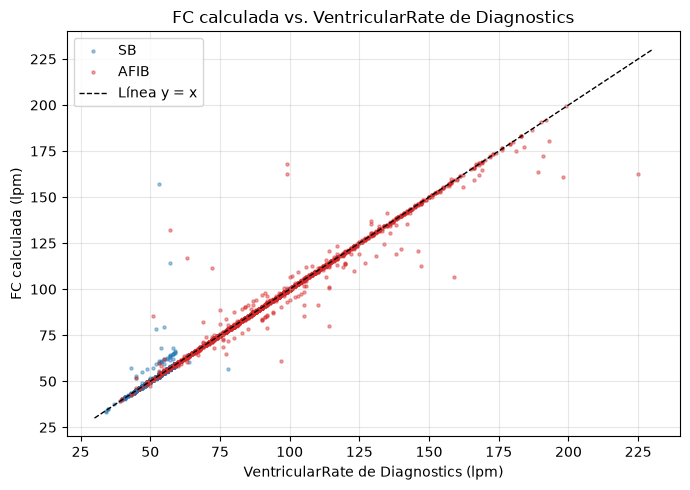

In [31]:
plt.figure(figsize=(7, 5))
for ritmo, color in [("SB", "tab:blue"), ("AFIB", "tab:red")]:
    grupo = resultados[resultados["Ritmo"] == ritmo]
    plt.scatter(grupo["FC_Diagnostics"], grupo["FC"], s=5, alpha=0.4, color=color, label=ritmo)
plt.plot([30, 230], [30, 230], "k--", linewidth=1, label="Línea y = x")
plt.title("FC calculada vs. VentricularRate de Diagnostics")
plt.xlabel("VentricularRate de Diagnostics (lpm)")
plt.ylabel("FC calculada (lpm)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

El error mediano es de 0.25 lpm en SB y 0.28 lpm en AFIB, y solo el 0.18 % de los SB y el 1.69 % de los AFIB se alejan más de 10 lpm del valor de Diagnostics; en la gráfica casi todos los puntos quedan sobre la línea y = x. La correlación es 0.985 en AFIB y menor en SB (0.875), pero no porque el método sea peor, sino porque en SB casi todos los valores están en un rango muy estrecho, justo por debajo de 60 lpm, y ahí unos pocos errores pesan mucho en la correlación. Por eso tomamos la FC calculada como confiable. Los pocos registros con error los dejamos en el análisis, porque no tenemos un criterio claro para quitarlos y las pruebas no paramétricas se afectan poco por valores extremos.

### 3.3 Estadística descriptiva

In [32]:
caracteristicas = ["Media", "Desviacion", "Maximo", "Minimo", "FC", "RMS"]
unidades = {"Media": "µV", "Desviacion": "µV", "Maximo": "µV", "Minimo": "µV", "FC": "lpm", "RMS": "µV"}
nombres_car = {"Media": "Media", "Desviacion": "Desviación estándar", "Maximo": "Valor máximo",
               "Minimo": "Valor mínimo", "FC": "Frecuencia cardíaca", "RMS": "Valor RMS"}

sb = resultados[resultados["Ritmo"] == "SB"]
afib = resultados[resultados["Ritmo"] == "AFIB"]
print("n SB =", len(sb), "| n AFIB =", len(afib))

filas_desc = []
for car in caracteristicas:
    for ritmo, grupo in [("SB", sb), ("AFIB", afib)]:
        datos = grupo[car]
        filas_desc.append([f"{nombres_car[car]} ({unidades[car]})", ritmo, np.mean(datos), np.std(datos, ddof=1),
                           np.median(datos), np.percentile(datos, 25), np.percentile(datos, 75),
                           np.min(datos), np.max(datos)])

descriptiva = pd.DataFrame(filas_desc, columns=["Característica", "Grupo", "Promedio", "Desv. est.", "Mediana",
                                                "Q1", "Q3", "Mín.", "Máx."])
descriptiva.round(2)

n SB = 3888 | n AFIB = 1780


,Característica,Grupo,Promedio,Desv. est.,Mediana,Q1,Q3,Mín.,Máx.
0,Media (µV),SB,32.80,17.50,32.57,21.29,43.62,-70.97,138.03
1,Media (µV),AFIB,24.29,23.50,22.96,10.80,36.83,-104.95,121.63
2,Desviación estándar (µV),SB,116.60,45.69,110.50,84.82,140.43,19.34,525.97
3,Desviación estándar (µV),AFIB,129.01,63.82,115.14,83.11,159.21,19.87,521.21
4,Valor máximo (µV),SB,849.10,392.74,807.68,573.48,1063.22,58.26,7263.70
5,Valor máximo (µV),AFIB,795.32,430.04,727.84,497.82,1009.62,58.84,4773.10
6,Valor mínimo (µV),SB,-192.56,202.48,-144.38,-248.24,-82.29,-7660.50,-13.29
7,Valor mínimo (µV),AFIB,-287.31,369.14,-188.72,-358.32,-94.31,-8575.60,-17.75
8,Frecuencia cardíaca (lpm),SB,55.14,4.44,55.98,53.08,57.89,33.55,157.23
9,Frecuencia cardíaca (lpm),AFIB,95.37,26.88,91.24,76.33,109.26,39.04,199.25


### 3.4 Diagramas de caja (box plots)

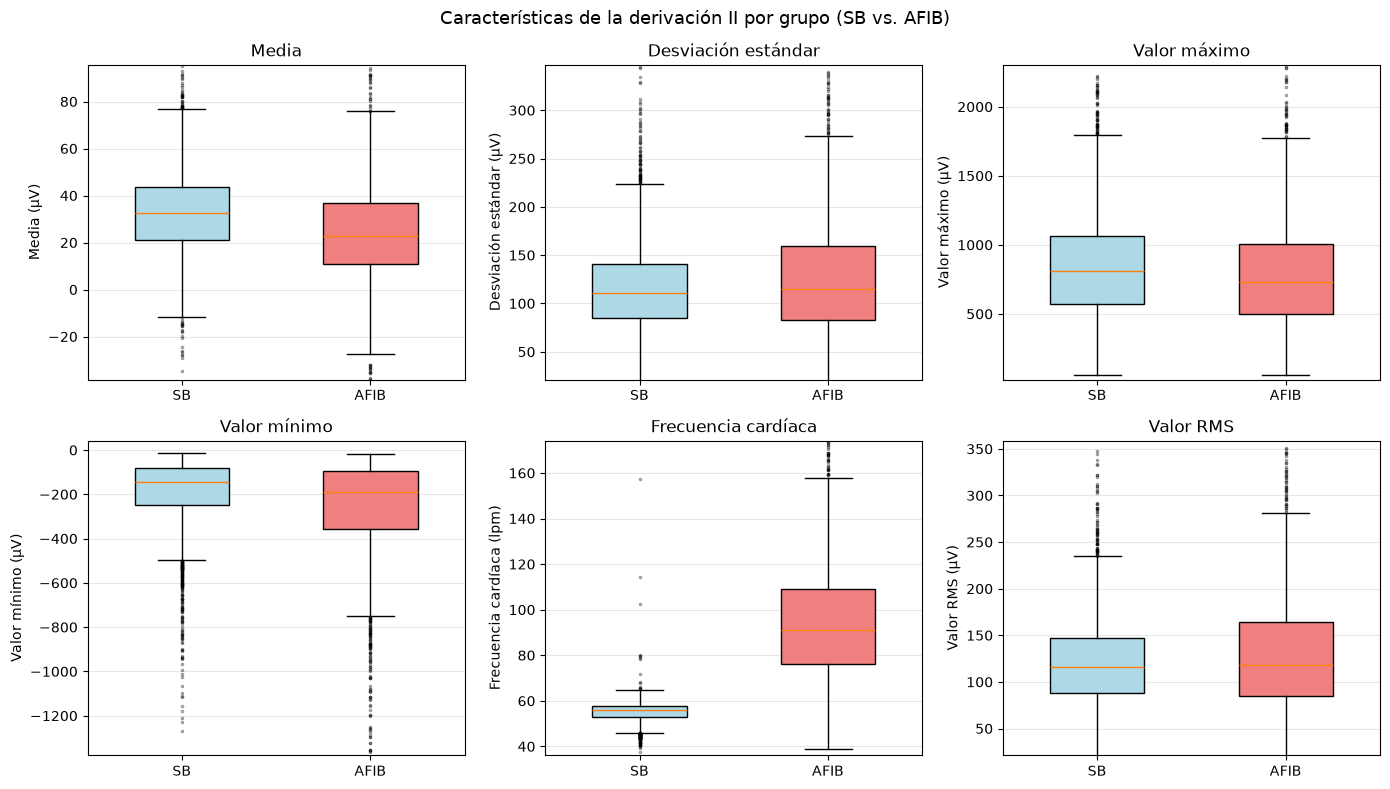

In [33]:
plt.figure(figsize=(14, 8))
for i, car in enumerate(caracteristicas):
    plt.subplot(2, 3, i + 1)
    cajas = plt.boxplot([sb[car], afib[car]], patch_artist=True, widths=0.5,
                        flierprops={"marker": ".", "markersize": 3, "alpha": 0.4})
    cajas["boxes"][0].set_facecolor("lightblue")
    cajas["boxes"][1].set_facecolor("lightcoral")
    # eje y entre los percentiles 0.5 y 99.5 para que los atípicos extremos no aplasten las cajas
    limite_inf = np.percentile(resultados[car], 0.5)
    limite_sup = np.percentile(resultados[car], 99.5)
    margen = 0.05 * (limite_sup - limite_inf)
    plt.ylim(limite_inf - margen, limite_sup + margen)
    plt.xticks([1, 2], ["SB", "AFIB"])
    plt.title(nombres_car[car])
    plt.ylabel(f"{nombres_car[car]} ({unidades[car]})")
    plt.grid(True, axis="y", alpha=0.3)
plt.suptitle("Características de la derivación II por grupo (SB vs. AFIB)", fontsize=13)
plt.tight_layout()
plt.show()

Para que se vean bien las cajas, el eje y de cada gráfica va entre los percentiles 0.5 y 99.5; los valores más extremos quedan por fuera, pero se pueden ver en las columnas de mínimo y máximo de la tabla anterior.

- **FC:** es la diferencia más clara. Las cajas ni se tocan y la de AFIB es mucho más alta y ancha, o sea que en AFIB la FC es mayor y cambia mucho más de un paciente a otro.
- **Media:** es un poco mayor en SB. Como el filtro quitó la línea de base, la media no da cero sino que refleja el balance entre las áreas positivas y negativas de las ondas; en la derivación II normalmente la R y la T son positivas, por eso la media sale positiva.
- **Máximo y mínimo:** SB tiene máximos un poco más altos y AFIB tiene mínimos más negativos. En los dos grupos hay valores atípicos muy grandes que probablemente son artefactos o latidos anormales.
- **Desviación estándar y RMS:** las cajas se parecen mucho; la de AFIB es apenas un poco más alta y ancha. Estas dos medidas dan casi lo mismo porque la media de la señal es pequeña comparada con su variación (RMS² = media² + desviación²).

En casi todas las características hay muchos valores atípicos hacia un solo lado, lo que ya sugiere distribuciones asimétricas.

### 3.5 Diagramas de densidad

Graficamos el histograma normalizado (`density=True`) de cada grupo y encima una estimación de densidad por kernel (`scipy.stats.gaussian_kde`). Para que se vea la forma principal de la distribución, el eje x se limita entre los percentiles 0.5 y 99.5 de los datos (los valores extremos siguen incluidos en todas las pruebas).

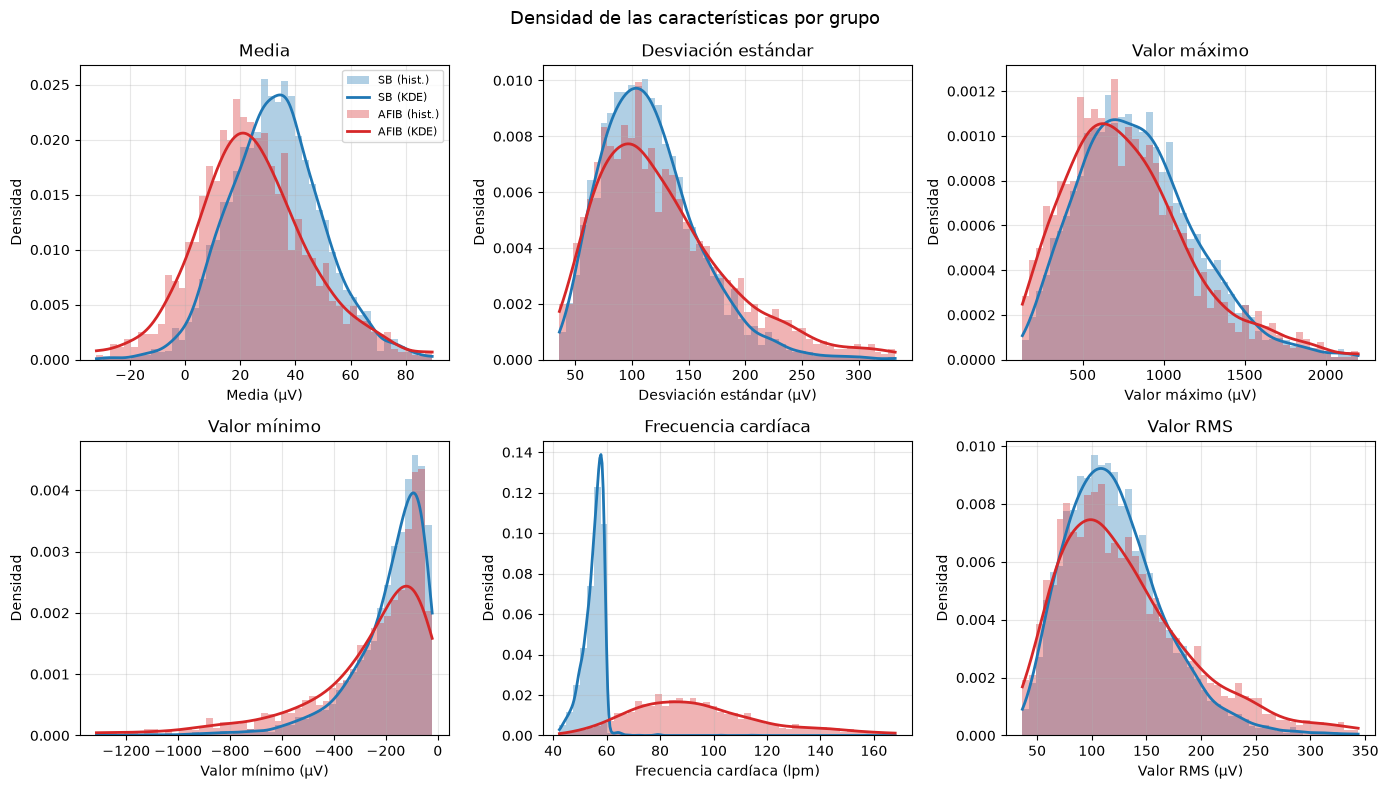

In [34]:
plt.figure(figsize=(14, 8))
for i, car in enumerate(caracteristicas):
    plt.subplot(2, 3, i + 1)
    limite_inf = np.percentile(resultados[car], 0.5)
    limite_sup = np.percentile(resultados[car], 99.5)
    bordes = np.linspace(limite_inf, limite_sup, 50)
    eje_x = np.linspace(limite_inf, limite_sup, 300)
    for datos, nombre, color in [(sb[car], "SB", "tab:blue"), (afib[car], "AFIB", "tab:red")]:
        plt.hist(datos, bins=bordes, density=True, alpha=0.35, color=color, label=f"{nombre} (hist.)")
        kde = stats.gaussian_kde(datos)
        plt.plot(eje_x, kde(eje_x), color=color, linewidth=2, label=f"{nombre} (KDE)")
    plt.title(nombres_car[car])
    plt.xlabel(f"{nombres_car[car]} ({unidades[car]})")
    plt.ylabel("Densidad")
    plt.grid(True, alpha=0.3)
    if i == 0:
        plt.legend(fontsize=8)
plt.suptitle("Densidad de las características por grupo", fontsize=13)
plt.tight_layout()
plt.show()

Las densidades muestran lo mismo que los boxplots. La FC de SB es un pico muy alto y angosto justo por debajo de 60 lpm (por la misma definición de bradicardia), mientras que la de AFIB es una curva ancha y baja; las dos casi no se traslapan. En la media, la curva de AFIB está corrida hacia la izquierda respecto a la de SB. En la desviación, el máximo y el RMS las curvas se superponen casi por completo y tienen colas largas hacia la derecha (asimetría positiva); en el mínimo la cola larga va hacia la izquierda. Ninguna de estas formas es una campana simétrica, así que ya sospechábamos que la normalidad no se iba a cumplir.

### 3.6 Hipótesis

Para cada característica planteamos:

- **H₀:** la característica tiene la misma distribución en los registros de bradicardia sinusal y en los de fibrilación auricular, es decir, no hay diferencia entre SB y AFIB.
- **H₁:** la característica es diferente entre SB y AFIB (prueba bilateral).

Si se llega a usar la prueba t, las hipótesis se escriben con medias: H₀: μ_SB = μ_AFIB y H₁: μ_SB ≠ μ_AFIB. Si se usa Mann-Whitney, lo que se compara es si los valores de un grupo tienden a ser mayores que los del otro; como apoyo reportamos las medianas. En todos los casos usamos **α = 0.05**.

### 3.7 Verificación de los supuestos de la prueba t

La prueba t de Student para muestras independientes supone: (1) que la variable es normal en cada grupo, (2) que las observaciones son independientes y (3) que las varianzas de los grupos son iguales (homocedasticidad).

#### 3.7.1 Normalidad

Usamos la prueba de D'Agostino-Pearson (`stats.normaltest`) [3], [7], que se basa en la asimetría y la curtosis; su H₀ es que los datos vienen de una distribución normal. Hay que tener en cuenta que con miles de registros cualquier prueba de normalidad (Shapiro-Wilk, D'Agostino o Kolmogorov-Smirnov) marca como "no normal" hasta desviaciones pequeñas, por eso además miramos la asimetría, la curtosis y los QQ plots. También probamos Kolmogorov-Smirnov y dio la misma conclusión, así que no lo incluimos.

In [35]:
filas_normalidad = []
for car in caracteristicas:
    for ritmo, grupo in [("SB", sb), ("AFIB", afib)]:
        datos = grupo[car]
        k2, p_dagostino = stats.normaltest(datos)
        filas_normalidad.append([car, ritmo, len(datos), stats.skew(datos), stats.kurtosis(datos),
                                 k2, texto_p(p_dagostino), "Sí" if p_dagostino > ALFA else "No"])

tabla_normalidad = pd.DataFrame(filas_normalidad, columns=["Característica", "Grupo", "n", "Asimetría", "Curtosis (exceso)",
                                                           "K² D'Agostino", "p-valor", "¿Normal?"])
tabla_normalidad.round(3)

,Característica,Grupo,n,Asimetría,Curtosis (exceso),K² D'Agostino,p-valor,¿Normal?
0,Media,SB,3888,0.143,1.166,107.704,4.095e-24,No
1,Media,AFIB,1780,-0.146,3.025,137.838,1.172e-30,No
2,Desviacion,SB,3888,1.331,4.565,1098.792,2.514e-239,No
3,Desviacion,AFIB,1780,1.398,3.006,472.819,2.131e-103,No
4,Maximo,SB,3888,1.849,19.061,1995.022,< 1e-300,No
5,Maximo,AFIB,1780,1.491,5.900,601.758,2.137e-131,No
6,Minimo,SB,3888,-14.268,479.605,7456.343,< 1e-300,No
7,Minimo,AFIB,1780,-9.414,172.735,2781.682,< 1e-300,No
8,FC,SB,3888,3.480,84.573,3512.320,< 1e-300,No
9,FC,AFIB,1780,0.841,0.600,179.798,9.064e-40,No


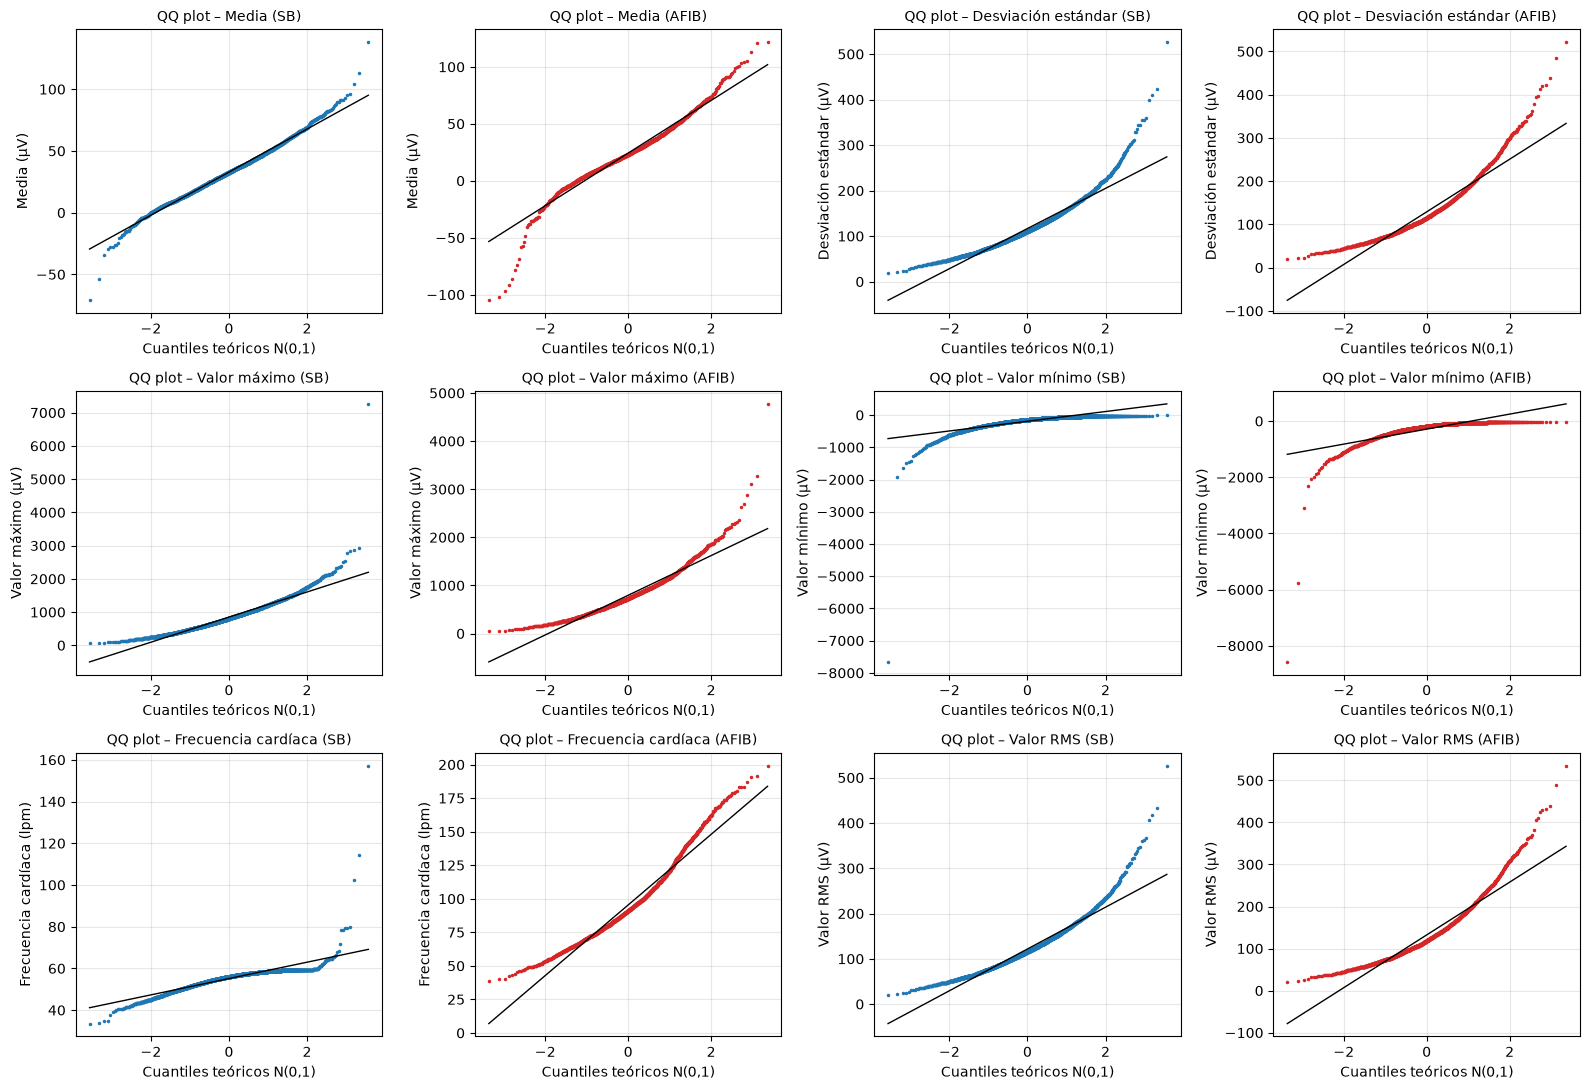

In [36]:
plt.figure(figsize=(16, 11))
posicion = 1
for car in caracteristicas:
    for ritmo, grupo, color in [("SB", sb, "tab:blue"), ("AFIB", afib, "tab:red")]:
        plt.subplot(3, 4, posicion)
        (x_teorico, y_ordenado), (pendiente, intercepto, r) = stats.probplot(grupo[car], dist="norm")
        plt.plot(x_teorico, y_ordenado, ".", color=color, markersize=3)
        plt.plot(x_teorico, pendiente * x_teorico + intercepto, "k-", linewidth=1)
        plt.title(f"QQ plot – {nombres_car[car]} ({ritmo})", fontsize=10)
        plt.xlabel("Cuantiles teóricos N(0,1)")
        plt.ylabel(f"{nombres_car[car]} ({unidades[car]})")
        plt.grid(True, alpha=0.3)
        posicion += 1
plt.tight_layout()
plt.show()

Ninguna característica pasa la prueba de normalidad en ninguno de los dos grupos: todos los p-valores de D'Agostino son menores que 0.05 (el más alto es 4.095e-24, en la media de SB). La asimetría y la curtosis muestran por qué: por ejemplo, el mínimo tiene una asimetría de −14.27 en SB y −9.41 en AFIB, y la FC de SB tiene una curtosis de 84.57 por los pocos registros con FC muy alta o mal estimada. En los QQ plots (la línea negra es la recta de una distribución normal) se ve lo mismo: los puntos se apartan de la recta en los extremos, sobre todo en el mínimo, el máximo y la FC de SB. La media es la que más se acerca a la recta, pero sus colas también se desvían.

Por lo tanto, el supuesto de normalidad no se cumple en ninguna característica. Con muestras tan grandes la prueba t igual funcionaría bastante bien por el teorema del límite central, pero seguimos lo que pide la guía y, si no hay normalidad, pasamos a la prueba no paramétrica.

#### 3.7.2 Independencia

Este supuesto no se prueba con un test, se argumenta con el diseño de los datos. Cada archivo corresponde a un paciente distinto (1 registro de 10 s por paciente, como vimos en la sección 1.2) y cada paciente tiene un solo ritmo asignado, así que un registro de SB no tiene relación con uno de AFIB. Por lo tanto, consideramos que los dos grupos son independientes y que las observaciones dentro de cada grupo también lo son.

#### 3.7.3 Homocedasticidad (prueba de Levene)

H₀: las varianzas de SB y AFIB son iguales; H₁: son diferentes. Usamos `stats.levene` [3], [8] con su opción por defecto (`center="median"`), que es la que se recomienda cuando los datos no son normales.

In [37]:
filas_levene = []
for car in caracteristicas:
    w, p_levene = stats.levene(sb[car], afib[car])
    filas_levene.append([car, np.var(sb[car], ddof=1), np.var(afib[car], ddof=1), w, texto_p(p_levene),
                         "Sí" if p_levene > ALFA else "No"])

tabla_levene = pd.DataFrame(filas_levene, columns=["Característica", "Varianza SB", "Varianza AFIB",
                                                   "W (Levene)", "p-valor", "¿Varianzas iguales?"])
tabla_levene.round(2)

,Característica,Varianza SB,Varianza AFIB,W (Levene),p-valor,¿Varianzas iguales?
0,Media,306.31,552.22,95.73,1.979e-22,No
1,Desviacion,2087.83,4072.80,156.80,1.669e-35,No
2,Maximo,154247.94,184935.23,8.21,4.177e-03,No
3,Minimo,40999.08,136261.87,135.12,6.947e-31,No
4,FC,19.68,722.44,3565.91,< 1e-300,No
5,RMS,2266.24,4328.44,145.01,5.384e-33,No


En las seis características el p-valor de Levene es menor que 0.05, así que las varianzas no son iguales. En todas, AFIB tiene más varianza que SB; el caso más extremo es la FC, donde la varianza de AFIB (722.44 lpm²) es unas 37 veces la de SB (19.68 lpm²). Esto tiene sentido: en AFIB la FC depende de cuántos impulsos deja pasar el nodo AV, y eso cambia mucho de un paciente a otro, mientras que en SB todos quedan en un rango estrecho por debajo de 60 lpm.

Entonces, de los tres supuestos solo se cumple la independencia. Por eso usamos la **prueba U de Mann-Whitney** en todas las características.

### 3.8 Aplicación de la prueba estadística

La regla para escoger la prueba en cada característica es:

1. Si los dos grupos son normales y las varianzas son iguales → **t de Student** para muestras independientes [9].
2. Si los dos grupos son normales pero las varianzas no son iguales → **t de Welch** (`equal_var=False`).
3. Si algún grupo no es normal → **U de Mann-Whitney** (no paramétrica, compara rangos) [10].

Como complemento calculamos un tamaño de efecto sencillo. Para Mann-Whitney usamos la correlación biserial de rangos, r = 2·U/(n₁·n₂) − 1, que va de −1 a 1: vale 0 si no hay diferencia, se acerca a +1 si casi siempre SB > AFIB y a −1 si casi siempre SB < AFIB. De referencia aproximada, un valor absoluto cerca de 0.1 se considera pequeño, 0.3 mediano y 0.5 o más grande. (Si se usara la t, reportaríamos la d de Cohen.)

Además, como se hacen 6 pruebas, en la sección 4 también revisamos las decisiones con la corrección de Bonferroni (α dividido entre el número de pruebas).

In [38]:
filas_pruebas = []
for car in caracteristicas:
    x_sb = sb[car]
    x_afib = afib[car]
    normal = tabla_normalidad[(tabla_normalidad["Característica"] == car)]["¿Normal?"].eq("Sí").all()
    varianzas_iguales = tabla_levene.set_index("Característica").loc[car, "¿Varianzas iguales?"] == "Sí"

    if normal and varianzas_iguales:
        prueba = "t de Student"
        estadistico, p = stats.ttest_ind(x_sb, x_afib)
    elif normal:
        prueba = "t de Welch"
        estadistico, p = stats.ttest_ind(x_sb, x_afib, equal_var=False)
    else:
        prueba = "U de Mann-Whitney"
        estadistico, p = stats.mannwhitneyu(x_sb, x_afib, alternative="two-sided")

    if prueba == "U de Mann-Whitney":
        efecto = 2 * estadistico / (len(x_sb) * len(x_afib)) - 1
        nombre_efecto = "r biserial de rangos"
    else:
        s_combinada = np.sqrt(((len(x_sb) - 1) * np.var(x_sb, ddof=1) + (len(x_afib) - 1) * np.var(x_afib, ddof=1))
                              / (len(x_sb) + len(x_afib) - 2))
        efecto = (np.mean(x_sb) - np.mean(x_afib)) / s_combinada
        nombre_efecto = "d de Cohen"

    decision = "Se rechaza H0" if p < ALFA else "No se rechaza H0"
    filas_pruebas.append([car, prueba, estadistico, p, texto_p(p), decision,
                          np.median(x_sb), np.median(x_afib), nombre_efecto, efecto])

tabla_pruebas = pd.DataFrame(filas_pruebas, columns=["Característica", "Prueba", "Estadístico", "p", "p-valor", "Decisión (α = 0.05)",
                                                     "Mediana SB", "Mediana AFIB", "Tamaño de efecto", "Valor efecto"])
tabla_pruebas.drop(columns="p").round(3)

,Característica,Prueba,Estadístico,p-valor,Decisión (α = 0.05),Mediana SB,Mediana AFIB,Tamaño de efecto,Valor efecto
0,Media,U de Mann-Whitney,4359416.0,1.032e-55,Se rechaza H0,32.566,22.962,r biserial de rangos,0.260
1,Desviacion,U de Mann-Whitney,3199718.0,5.173e-06,Se rechaza H0,110.498,115.138,r biserial de rangos,-0.075
2,Maximo,U de Mann-Whitney,3830393.5,9.659e-11,Se rechaza H0,807.680,727.840,r biserial de rangos,0.107
3,Minimo,U de Mann-Whitney,4048033.0,8.810e-25,Se rechaza H0,-144.375,-188.725,r biserial de rangos,0.170
4,FC,U de Mann-Whitney,222992.5,< 1e-300,Se rechaza H0,55.983,91.237,r biserial de rangos,-0.936
5,RMS,U de Mann-Whitney,3280547.0,1.666e-03,Se rechaza H0,115.720,118.240,r biserial de rangos,-0.052


## 4. Interpretación de los resultados

La siguiente tabla reúne, para cada prueba, lo que pide la guía: prueba utilizada, hipótesis, nivel de significancia, estadístico, p-valor y decisión. También incluye las medianas y el tamaño de efecto. Después se interpreta cada característica en el contexto del ECG.

In [39]:
def magnitud_efecto(r):
    # umbrales aproximados: 0.1 pequeño, 0.3 mediano, 0.5 grande
    if abs(r) < 0.1:
        return "muy pequeño"
    elif abs(r) < 0.3:
        return "pequeño"
    elif abs(r) < 0.5:
        return "mediano"
    return "grande"


alfa_bonferroni = ALFA / len(caracteristicas)
print(f"α con corrección de Bonferroni: {ALFA} / {len(caracteristicas)} = {alfa_bonferroni:.4f}")
print("p-valor más alto de las 6 pruebas:", texto_p(tabla_pruebas["p"].max()))

resumen = pd.DataFrame({
    "Prueba utilizada": tabla_pruebas["Prueba"].values,
    "H0": ["Distribución igual en SB y AFIB"] * len(caracteristicas),
    "H1": ["Distribución diferente en SB y AFIB (bilateral)"] * len(caracteristicas),
    "α": [ALFA] * len(caracteristicas),
    "Estadístico": tabla_pruebas["Estadístico"].round(1).values,
    "p-valor": tabla_pruebas["p-valor"].values,
    "Decisión": tabla_pruebas["Decisión (α = 0.05)"].values,
    "Mediana SB": tabla_pruebas["Mediana SB"].round(2).values,
    "Mediana AFIB": tabla_pruebas["Mediana AFIB"].round(2).values,
    "Efecto (r)": tabla_pruebas["Valor efecto"].round(3).values,
    "Magnitud": [magnitud_efecto(r) for r in tabla_pruebas["Valor efecto"]],
}, index=[f"{nombres_car[c]} ({unidades[c]})" for c in caracteristicas])
resumen

α con corrección de Bonferroni: 0.05 / 6 = 0.0083
p-valor más alto de las 6 pruebas: 1.666e-03


,Prueba utilizada,H0,H1,α,Estadístico,p-valor,Decisión,Mediana SB,Mediana AFIB,Efecto (r),Magnitud
Media (µV),U de Mann-Whitney,Distribución igual en SB y AFIB,Distribución diferente en SB y AFIB (bilateral),0.05,4359416.0,1.032e-55,Se rechaza H0,32.57,22.96,0.260,pequeño
Desviación estándar (µV),U de Mann-Whitney,Distribución igual en SB y AFIB,Distribución diferente en SB y AFIB (bilateral),0.05,3199718.0,5.173e-06,Se rechaza H0,110.50,115.14,-0.075,muy pequeño
Valor máximo (µV),U de Mann-Whitney,Distribución igual en SB y AFIB,Distribución diferente en SB y AFIB (bilateral),0.05,3830393.5,9.659e-11,Se rechaza H0,807.68,727.84,0.107,pequeño
Valor mínimo (µV),U de Mann-Whitney,Distribución igual en SB y AFIB,Distribución diferente en SB y AFIB (bilateral),0.05,4048033.0,8.810e-25,Se rechaza H0,-144.38,-188.72,0.170,pequeño
Frecuencia cardíaca (lpm),U de Mann-Whitney,Distribución igual en SB y AFIB,Distribución diferente en SB y AFIB (bilateral),0.05,222992.5,< 1e-300,Se rechaza H0,55.98,91.24,-0.936,grande
Valor RMS (µV),U de Mann-Whitney,Distribución igual en SB y AFIB,Distribución diferente en SB y AFIB (bilateral),0.05,3280547.0,1.666e-03,Se rechaza H0,115.72,118.24,-0.052,muy pequeño


Antes de ver cada característica, un comentario general: con miles de registros, las pruebas detectan como "significativas" hasta diferencias muy pequeñas. Por eso no nos quedamos solo con el p-valor: también miramos el tamaño de efecto (r) y las medianas para ver si la diferencia importa en la práctica. Con la corrección de Bonferroni el α baja a 0.0083 y el p-valor más alto de las seis pruebas (el del RMS) sigue siendo menor, así que ninguna decisión cambia.

#### 4.1 Media

Se rechaza H₀: la media de la derivación II es diferente entre los grupos y tiende a ser mayor en SB, aunque el efecto es pequeño. Es decir, si se toma al azar un registro de cada grupo, es más probable que el de SB tenga la media más alta, pero muchas veces no pasa. Como la línea de base fue removida, la media mide el balance de áreas de las ondas. En SB cada latido tiene su onda P y su onda T positivas en la derivación II; en AFIB no hay onda P y, como vimos en el ejemplo, pueden aparecer S más profundas que restan área. Esa puede ser una explicación, aunque con este análisis no la podemos comprobar.

#### 4.2 Desviación estándar

También se rechaza H₀, pero en la práctica la diferencia es mínima: las medianas son casi iguales y el efecto es muy pequeño. O sea que la variabilidad de amplitud de la señal en 10 s es parecida en los dos ritmos. Tiene lógica: en AFIB hay más latidos en los 10 s (más QRS, que es lo que más aporta a la desviación), pero sus ondas R suelen ser más bajas, así que un efecto compensa al otro. Por sí sola, la desviación estándar de la señal completa no ayuda mucho a diferenciar estas dos arritmias.

#### 4.3 Valor máximo

El máximo también sale con diferencia significativa (se rechaza H₀). Como casi siempre es el pico de la onda R, esto quiere decir que la R tiende a ser un poco más alta en SB, pero el efecto es pequeño y las distribuciones se traslapan mucho. Una posible razón es que los pacientes con AFIB son en promedio mayores (sección 1.4), aunque este análisis no permite separar el efecto de la edad del efecto del ritmo. Además, el máximo es muy sensible a artefactos: un solo pico raro cambia su valor.

#### 4.4 Valor mínimo

Con el mínimo también se rechaza H₀. En AFIB los valores mínimos son más negativos y además varían más entre pacientes. El mínimo suele ser el fondo de la onda Q o de la S, así que en el grupo AFIB son más comunes las deflexiones negativas profundas en la derivación II. Una posible explicación es que en este grupo hay pacientes mayores y con otras condiciones asociadas (como el bloqueo de rama del ejemplo), aunque no lo verificamos. El efecto es pequeño, así que tampoco es una característica que separe bien los grupos.

#### 4.5 Frecuencia cardíaca

Aquí está la diferencia más fuerte de todas: se rechaza H₀ y el efecto es grande y negativo, o sea que un registro de SB casi nunca tiene mayor FC que uno de AFIB y los grupos casi no se traslapan. Esto coincide con la teoría: la bradicardia sinusal se define por una FC menor a 60 lpm, mientras que en la fibrilación auricular el nodo AV recibe impulsos auriculares muy rápidos y desorganizados y los ventrículos responden con una frecuencia normal o alta, además de irregular. De las seis características, la FC es la que está más directamente relacionada con el tipo de arritmia.

#### 4.6 Valor RMS

Con el RMS pasa lo mismo que con la desviación estándar: se rechaza H₀, pero el efecto es muy pequeño y el RMS es apenas mayor en AFIB. El RMS mide el nivel de amplitud promedio de la señal, y en los dos ritmos es casi el mismo. Los dos valores casi coinciden porque la media de la señal es pequeña, así que la conclusión es igual: el nivel de energía de la derivación II casi no distingue entre SB y AFIB.

## 5. Conclusiones

- La base de datos de Chapman/Shaoxing tiene 10646 registros de 10646 pacientes distintos, con 12 derivaciones, 500 Hz y 10 s por registro, y 11 ritmos muy desbalanceados. Al explorarla encontramos tres detalles menores (las siglas SI/SA, el número de AFIB que reporta el artículo y un archivo filtrado de SB incompleto) que no cambian la comparación entre SB y AFIB.
- En los registros de ejemplo se ven claramente las diferencias de cada arritmia: la SB es un ritmo sinusal lento y regular con ondas P visibles, y la AFIB no tiene ondas P, muestra ondas f y tiene intervalos RR irregulares.
- Para medir la FC en miles de registros no bastó con aplicar `find_peaks` directamente sobre la señal; con la derivada al cuadrado la FC calculada coincidió muy bien con la frecuencia ventricular de Diagnostics.
- Ninguna característica cumplió normalidad ni homocedasticidad, así que se usó la U de Mann-Whitney en todos los casos. Las seis características resultaron con diferencias estadísticamente significativas entre SB y AFIB, también con la corrección de Bonferroni.
- Sin embargo, que sea significativo no quiere decir que la diferencia sea importante. Solo la frecuencia cardíaca tuvo un efecto grande (r = −0.936); la media, el máximo y el mínimo tuvieron efectos pequeños, y la desviación estándar y el RMS, muy pequeños. Con muestras tan grandes casi cualquier diferencia sale significativa, así que para interpretar nos sirvieron más el tamaño del efecto y las gráficas que el p-valor.
- Las medidas estadísticas "globales" de la señal (media, desviación, máximo, mínimo, RMS) describen su amplitud, pero no dicen casi nada sobre el ritmo, que es lo que realmente diferencia una arritmia de otra. Para distinguir SB de AFIB son más útiles las medidas basadas en los latidos, como la FC y la variabilidad de los intervalos RR.
- Limitaciones: los grupos no son comparables en edad (los pacientes con AFIB son mayores) y muchos pacientes tienen otras condiciones en la columna `Beat`, lo que puede influir en las amplitudes. Además, solo se analizó la derivación II. Un trabajo posterior podría controlar la edad o incluir una característica de regularidad (por ejemplo, el CV de los RR) en la comparación.

## 6. Referencias

[1] J. Zheng, J. Zhang, S. Danioko, H. Yao, H. Guo y C. Rakovski, "A 12-lead electrocardiogram database for arrhythmia research covering more than 10,000 patients," *Scientific Data*, vol. 7, art. 48, 2020. doi: 10.1038/s41597-020-0386-x. Disponible: https://www.nature.com/articles/s41597-020-0386-x

[2] J. Zheng *et al.*, "A 12-lead electrocardiogram database for arrhythmia research covering more than 10,000 patients" (colección de datos), figshare, 2019. doi: 10.6084/m9.figshare.c.4560497. Disponible: https://figshare.com/collections/ChapmanECG/4560497

[3] SciPy Developers, "Statistical functions (scipy.stats)" y "scipy.signal.find_peaks," *SciPy Documentation*. Disponible: https://docs.scipy.org/doc/scipy/reference/stats.html y https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html (consultado: 24 sep. 2026).

[4] Y. Hafeez y S. A. Grossman, "Sinus Bradycardia," en *StatPearls*. Treasure Island, FL, EE. UU.: StatPearls Publishing, act. 7 ago. 2023. Disponible: https://www.ncbi.nlm.nih.gov/books/NBK493201/

[5] Z. Nesheiwat, A. Goyal y M. Jagtap, "Atrial Fibrillation," en *StatPearls*. Treasure Island, FL, EE. UU.: StatPearls Publishing, act. 26 abr. 2023. Disponible: https://www.ncbi.nlm.nih.gov/books/NBK526072/

[6] J. A. Joglar *et al.*, "2023 ACC/AHA/ACCP/HRS Guideline for the Diagnosis and Management of Atrial Fibrillation," *Circulation*, vol. 149, no. 1, pp. e1–e156, 2024. doi: 10.1161/CIR.0000000000001193.

[7] T. Haslwanter, "ISP_checkNormality.py," repositorio *statsintro_python*, GitHub. Disponible: https://github.com/thomas-haslwanter/statsintro_python/blob/master/ISP/Code_Quantlets/07_CheckNormality_CalcSamplesize/checkNormality/ISP_checkNormality.py (consultado: 24 sep. 2026).

[8] J. Amat Rodrigo, "Análisis de homocedasticidad y heterocedasticidad con python," *Ciencia de Datos*, 2021. Disponible: https://www.cienciadedatos.net/documentos/pystats07-test-homocedasticidad-heterocedasticidad-python.html (consultado: 24 sep. 2026).

[9] J. Amat Rodrigo, "T-test con Python," *Ciencia de Datos*, 2021. Disponible: https://www.cienciadedatos.net/documentos/pystats10-t-test-python.html (consultado: 24 sep. 2026).

[10] jmyao17, "Nonparametric Statistical Significance Tests," *GitHub Pages*. Disponible: https://jmyao17.github.io/Statistics/Nonparametric_Statistical_Significance_Tests.html (consultado: 24 sep. 2026).